# **THEMATIC COMMUNITIES IN THE MUSIC THEORY CITATION NETWORK**

#### **Authors**
- **Denish Patel** - *Princeton University*
- **Liuyang Xu** - *Rutgers University–New Brunswick*


#### **Acknowledgements**
TBD


## **Project Objectives**

1. **Construct the citation network.** Build a paper-level citation graph from the GitHub dataset where nodes represent articles or cited documents, directed edges represent citations, and node attributes include publication date, authors, keywords, and text-derived features.
2. **Identify thematic communities in the literature.** Apply lecture community-detection methods to test whether the citation network separates into coherent clusters, then evaluate each cluster using keyword distributions, frequently cited references, representative authors or papers, and frequently occurring composer names or musical works.
3. **Measure thematic coherence of communities.** Quantify whether documents inside the same community are more similar than documents in different communities using keyword overlap, title-based cosine similarity, cited-reference similarity, and author or composer-name overlap.


# **1. Imports**


In [ ]:
import json
import os
import re
from collections import Counter, defaultdict
from math import comb
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from scipy.sparse.linalg import eigsh
from scipy.linalg import eigh

try:
    from google.colab import drive
except ImportError:
    drive = None


# **2. Setup**


In [ ]:
IN_COLAB = True

if IN_COLAB:
    drive.mount('/content/drive')

project_root_candidates = [
    Path.cwd(),
    Path.cwd() / 'Project',
    Path('/content/drive/MyDrive/Spring 2026/COS 520'),
]

project_root = next((path for path in project_root_candidates if (path / 'data').exists()), None)
if project_root is None:
    project_root = next((path for path in project_root_candidates if (path / 'Project' / 'data').exists()), None)
    if project_root is not None:
        project_root = project_root / 'Project'

if project_root is None:
    raise FileNotFoundError(
        'Could not locate the project data directory. Expected Project/data in the local workspace or data in a mounted Colab drive.'
    )

file_path = project_root / 'data'
print(f'Using project root: {project_root}')
print(f'Using data directory: {file_path}')


Mounted at /content/drive
Using project root: /content/drive/MyDrive/Spring 2026/COS 520
Using data directory: /content/drive/MyDrive/Spring 2026/COS 520/data


In [ ]:
# # for local use
# from pathlib import Path

# project_root = Path.cwd()
# file_path = project_root / "data"

# print(f"Using project root: {project_root}")
# print(f"Using data directory: {file_path}")

# **3. Data Processing**


In [ ]:
datasets = {}

for file in sorted(file_path.glob('*.json')):
    with open(file, 'r') as f:
        datasets[file.stem] = json.load(f)

print(f'Loaded {len(datasets)} JSON files from {file_path}')
print('Sample paper ids:', list(datasets.keys())[:10])


Loaded 984 JSON files from /content/drive/MyDrive/Spring 2026/COS 520/data
Sample paper ids: ['mto.00.6.1.agawu', 'mto.00.6.1.anku', 'mto.00.6.1.jenkins', 'mto.00.6.1.martinez', 'mto.00.6.1.meeus', 'mto.00.6.1.mirka', 'mto.00.6.1.perry', 'mto.00.6.1.rawlins', 'mto.00.6.1.roemjantsew', 'mto.00.6.1.vetter']


### 3.1 Cleaning Helpers

These helpers standardize raw JSON fields before we assemble paper-level and citation-level tables.


In [ ]:
def clean_text(value):
    if value is None:
        return ''
    text = str(value)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = text.replace(' ', ' ')
    return re.sub(r'\s+', ' ', text).strip()


def normalize_text(value):
    text = clean_text(value).lower()
    text = re.sub(r'[^a-z0-9]+', ' ', text)
    return ' '.join(text.split())


def count_paragraph_citations(paragraphs):
    if isinstance(paragraphs, dict):
        iterable = paragraphs.values()
    elif isinstance(paragraphs, list):
        iterable = paragraphs
    else:
        return 0

    total = 0
    for content in iterable:
        if isinstance(content, dict):
            cites = content.get('citations', [])
            if isinstance(cites, list):
                total += len(cites)
    return total


def extract_author_surnames(authors):
    surnames = []
    if not isinstance(authors, list):
        return surnames

    for author in authors:
        if not isinstance(author, str):
            continue
        if ',' in author:
            surnames.append(author.split(',')[0].strip().lower())
        else:
            surnames.append(author.split()[-1].strip().lower())
    return surnames


### 3.2 Build Analysis Tables

We convert the raw JSON corpus into a paper table and a citation table that the rest of the notebook reuses.


In [ ]:
papers_list = []
citation_rows = []

for paper_id, paper_data in datasets.items():
    row = dict(paper_data)
    row['id'] = paper_id

    author_info = row.get('author_info', [])
    row['author_names'] = '; '.join([a.get('name', '') for a in author_info if isinstance(a, dict) and a.get('name')])
    row['author_universities'] = '; '.join([a.get('university', '') for a in author_info if isinstance(a, dict) and a.get('university')])
    row['author_addresses'] = '; '.join([a.get('address', '') for a in author_info if isinstance(a, dict) and a.get('address')])
    row['author_emails'] = '; '.join([a.get('email', '') for a in author_info if isinstance(a, dict) and a.get('email')])

    citations = row.get('citations', {})
    row['citation_keys'] = list(citations.keys()) if isinstance(citations, dict) else []
    row['citation_texts'] = list(citations.values()) if isinstance(citations, dict) else []
    row['num_citations'] = len(row['citation_keys'])
    row['num_paragraph_citations'] = count_paragraph_citations(row.get('paragraphs', {}))

    row['author_list'] = row['authors'] if isinstance(row.get('authors'), list) else []
    row['keyword_list'] = row['keywords'] if isinstance(row.get('keywords'), list) else []
    row['title_clean'] = clean_text(row.get('title', ''))
    row['title_norm'] = normalize_text(row.get('title', ''))
    row['author_surnames'] = extract_author_surnames(row['author_list'])
    row['publication_date'] = pd.to_datetime(row.get('date'), errors='coerce')
    row['year'] = row['publication_date'].year if not pd.isna(row['publication_date']) else np.nan

    papers_list.append(row)

    if isinstance(citations, dict):
        for citation_key, citation_text in citations.items():
            citation_rows.append({
                'paper_id': paper_id,
                'citation_key': citation_key,
                'citation_text': citation_text,
            })

papers_df = pd.DataFrame(papers_list)
citations_df = pd.DataFrame(citation_rows)

print('papers_df shape:', papers_df.shape)
print('citations_df shape:', citations_df.shape)


papers_df shape: (984, 34)
citations_df shape: (25434, 3)


In [ ]:
display(papers_df.head())

,title,date,volume,issue,authors,abstract,keywords,doi,received,pdf,...,citation_texts,num_citations,num_paragraph_citations,author_list,keyword_list,title_clean,title_norm,author_surnames,publication_date,year
0,Response to Plenary Session,2000/01/01,6,1,"[Agawu, Kofi]",,[],,,http://www.mtosmt.org/issues/mto.00.6.1/mto.00...,...,[],0,0,"[Agawu, Kofi]",[],Response to Plenary Session,response to plenary session,[agawu],2000-01-01,2000.0
1,Circles and Time: A Theory of Structural Organ...,2000/01/01,6,1,"[Anku, Willie]",Much of African music is circular. This circul...,"[African music, rhythm, dance music, set theory]",,,http://www.mtosmt.org/issues/mto.00.6.1/mto.00...,...,"[Akpabot, Samuel. 1971. “Standard Drum Pattern...",32,0,"[Anku, Willie]","[African music, rhythm, dance music, set theory]",Circles and Time: A Theory of Structural Organ...,circles and time a theory of structural organi...,[anku],2000-01-01,2000.0
2,"Review of David Schiff, <i>The Music of Elliot...",2000/01/01,6,1,"[Jenkins, J. Daniel]",David Schiff’s 1998 second edition of theThe M...,"[Elliott Carter, David Schiff]",,,http://www.mtosmt.org/issues/mto.00.6.1/mto.00...,...,[],0,0,"[Jenkins, J. Daniel]","[Elliott Carter, David Schiff]","Review of David Schiff, The Music of Elliott C...",review of david schiff the music of elliott ca...,[jenkins],2000-01-01,2000.0
3,Semiotics and the Art Music of India,2000/01/01,6,1,"[Martinez, Jose Luis]",We know details of ancient classical music of ...,"[semiotics, Indian music, Peirce]",,,http://www.mtosmt.org/issues/mto.00.6.1/mto.00...,...,"[Bharata. 1967. The Natyashastra [Dramaturgy],...",18,0,"[Martinez, Jose Luis]","[semiotics, Indian music, Peirce]",Semiotics and the Art Music of India,semiotics and the art music of india,[martinez],2000-01-01,2000.0
4,Toward a Post-Schoenbergian Grammar of Tonal a...,2000/01/01,6,1,"[Meeus, Nicolas]",Schoenberg appears to have been among the firs...,"[Schoenberg, Rameau, fundamental bass, progres...",,,http://www.mtosmt.org/issues/mto.00.6.1/mto.00...,...,[],0,0,"[Meeus, Nicolas]","[Schoenberg, Rameau, fundamental bass, progres...",Toward a Post-Schoenbergian Grammar of Tonal a...,toward a post schoenbergian grammar of tonal a...,[meeus],2000-01-01,2000.0


In [ ]:
display(citations_df.head())

,paper_id,citation_key,citation_text
0,mto.00.6.1.anku,akpabot_1971,"Akpabot, Samuel. 1971. “Standard Drum Patterns..."
1,mto.00.6.1.anku,agawu_1995,"Agawu, Kofi. 1995. African Rhythm: A Northern ..."
2,mto.00.6.1.anku,anku_1992,"Anku, Willie. 1992. Structural Set Analysis of..."
3,mto.00.6.1.anku,anku_1993,"Anku, Willie. 1993. Structural Set Analysis of..."
4,mto.00.6.1.anku,anku_1995,"Anku, Willie. 1995. “Towards a Cross-cultural ..."


In [ ]:
citations_with_titles = citations_df.merge(
    papers_df[['id', 'title_clean']],
    left_on='paper_id',
    right_on='id',
    how='left'
).rename(columns={'title_clean': 'source_title'})

display(citations_with_titles.head())


,paper_id,citation_key,citation_text,id,source_title
0,mto.00.6.1.anku,akpabot_1971,"Akpabot, Samuel. 1971. “Standard Drum Patterns...",mto.00.6.1.anku,Circles and Time: A Theory of Structural Organ...
1,mto.00.6.1.anku,agawu_1995,"Agawu, Kofi. 1995. African Rhythm: A Northern ...",mto.00.6.1.anku,Circles and Time: A Theory of Structural Organ...
2,mto.00.6.1.anku,anku_1992,"Anku, Willie. 1992. Structural Set Analysis of...",mto.00.6.1.anku,Circles and Time: A Theory of Structural Organ...
3,mto.00.6.1.anku,anku_1993,"Anku, Willie. 1993. Structural Set Analysis of...",mto.00.6.1.anku,Circles and Time: A Theory of Structural Organ...
4,mto.00.6.1.anku,anku_1995,"Anku, Willie. 1995. “Towards a Cross-cultural ...",mto.00.6.1.anku,Circles and Time: A Theory of Structural Organ...


# **4. Objective 1: Construct the Citation Network**

We build a paper-level citation network by matching bibliography entries back to papers inside the MTO corpus using DOI links, MTO issue URLs, and conservative title-plus-author matching. Because direct internal citations remain sparse, we also construct a weighted bibliographic-coupling graph based on shared references for downstream thematic analysis.


### 4.0.1 Text Features and Citation Matching Helpers

Before building the graph, we derive simple text features and define conservative rules for matching bibliography entries back to papers in the corpus.


In [ ]:
def combine_text_fields(row):
    parts = [
        row.get('title_clean', ''),
        clean_text(row.get('abstract', '')),
        ' '.join(row.get('keyword_list', [])),
    ]
    return ' '.join(part for part in parts if part)


def top_tfidf_terms(tfidf_matrix, vectorizer, row_index, top_n=8):
    row = tfidf_matrix[row_index]
    if row.nnz == 0:
        return []
    features = vectorizer.get_feature_names_out()
    weights = row.toarray().ravel()
    top_idx = weights.argsort()[::-1][:top_n]
    return [features[i] for i in top_idx if weights[i] > 0]


In [ ]:
papers_df['feature_text'] = papers_df.apply(combine_text_fields, axis=1)
vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
paper_tfidf = vectorizer.fit_transform(papers_df['feature_text'].fillna(''))
papers_df['text_features'] = [top_tfidf_terms(paper_tfidf, vectorizer, idx) for idx in range(len(papers_df))]

doi_to_id = {
    clean_text(row.doi).lower(): row.id
    for row in papers_df.itertuples(index=False)
    if clean_text(getattr(row, 'doi', ''))
}

urlstem_to_id = {}
for row in papers_df.itertuples(index=False):
    for source_text in (getattr(row, 'pdf', ''), getattr(row, 'source', '')):
        match = re.search(r'(mto\.\d{2}\.\d{1,2}\.\d(?:\.[a-z0-9._-]+)?)', str(source_text).lower())
        if match:
            urlstem_to_id[match.group(1)] = row.id

title_records = [
    (row.title_norm, row.id, row.author_surnames)
    for row in papers_df.itertuples(index=False)
    if row.title_norm
]


In [ ]:
def match_internal_citation(citation_text):
    text_clean = clean_text(citation_text)
    text_lower = text_clean.lower()

    doi_match = re.search(r'10\.30535/mto\.\d+\.\d+\.\d+', text_lower)
    if doi_match:
        matched_id = doi_to_id.get(doi_match.group(0))
        if matched_id:
            return matched_id, 'doi'

    url_match = re.search(r'issues/(mto\.\d{2}\.\d{1,2}\.\d(?:\.[a-z0-9._-]+)?)', text_lower)
    if url_match:
        matched_id = urlstem_to_id.get(url_match.group(1))
        if matched_id:
            return matched_id, 'url'

    if 'music theory online' in text_lower or 'mtosmt.org' in text_lower:
        citation_norm = normalize_text(text_clean)
        for title_norm, paper_id, author_surnames in title_records:
            if len(title_norm) < 20:
                continue
            if title_norm in citation_norm:
                if author_surnames and not any(surname in text_lower for surname in author_surnames[:2]):
                    continue
                return paper_id, 'title'

    return None, None


### 4.0.2 Build the Citation and Coupling Graphs

We create the internal citation graph first, then a weighted bibliographic-coupling graph for thematic analysis.


In [ ]:
internal_edge_rows = []
for row in citations_df.itertuples(index=False):
    matched_target, match_method = match_internal_citation(row.citation_text)
    if matched_target and matched_target != row.paper_id:
        internal_edge_rows.append({
            'source_id': row.paper_id,
            'target_id': matched_target,
            'citation_key': row.citation_key,
            'citation_text': row.citation_text,
            'match_method': match_method,
        })

internal_edges_df = pd.DataFrame(internal_edge_rows).drop_duplicates(subset=['source_id', 'target_id', 'citation_key'])
match_summary_df = (
    internal_edges_df['match_method']
    .value_counts(dropna=False)
    .rename_axis('match_method')
    .reset_index(name='matched_citations')
)

paper_citation_graph = nx.DiGraph()
for row in papers_df.itertuples(index=False):
    paper_citation_graph.add_node(
        row.id,
        title=row.title_clean,
        publication_date=None if pd.isna(row.publication_date) else row.publication_date.strftime('%Y-%m-%d'),
        authors=row.author_list,
        keywords=row.keyword_list,
        text_features=row.text_features,
        category=row.category,
        year=None if pd.isna(row.year) else int(row.year),
    )

for row in internal_edges_df.itertuples(index=False):
    paper_citation_graph.add_edge(
        row.source_id,
        row.target_id,
        match_method=row.match_method,
        citation_key=row.citation_key,
    )

papers_df['internal_in_degree'] = papers_df['id'].map(dict(paper_citation_graph.in_degree())).fillna(0).astype(int)
papers_df['internal_out_degree'] = papers_df['id'].map(dict(paper_citation_graph.out_degree())).fillna(0).astype(int)
papers_df['has_internal_citation_link'] = (papers_df['internal_in_degree'] + papers_df['internal_out_degree']) > 0


In [ ]:
paper_reference_sets = papers_df.set_index('id')['citation_keys'].apply(lambda x: set(x) if isinstance(x, list) else set())
bibliographic_coupling_graph = nx.Graph()
bibliographic_coupling_graph.add_nodes_from(papers_df['id'])

paper_ids = papers_df['id'].tolist()
for i, source_id in enumerate(paper_ids):
    refs_i = paper_reference_sets[source_id]
    if not refs_i:
        continue
    for target_id in paper_ids[i + 1:]:
        refs_j = paper_reference_sets[target_id]
        shared_refs = refs_i & refs_j
        if len(shared_refs) >= 3:
            union_refs = refs_i | refs_j
            bibliographic_coupling_graph.add_edge(
                source_id,
                target_id,
                weight=len(shared_refs),
                jaccard=len(shared_refs) / len(union_refs) if union_refs else 0,
            )

print(f'Paper-citation graph nodes: {paper_citation_graph.number_of_nodes():,}')
print(f'Paper-citation graph edges: {paper_citation_graph.number_of_edges():,}')
print(f'Bibliographic-coupling graph edges: {bibliographic_coupling_graph.number_of_edges():,}')
display(match_summary_df)


Paper-citation graph nodes: 984
Paper-citation graph edges: 930
Bibliographic-coupling graph edges: 4,337


,match_method,matched_citations
0,title,587
1,url,258
2,doi,98


In [ ]:
node_attribute_preview = papers_df[[
    'id',
    'publication_date',
    'author_names',
    'keyword_list',
    'text_features',
    'internal_in_degree',
    'internal_out_degree',
]].head(5)

display(node_attribute_preview)


,id,publication_date,author_names,keyword_list,text_features,internal_in_degree,internal_out_degree
0,mto.00.6.1.agawu,2000-01-01,Kofi Agawu,[],"[session, response]",0,0
1,mto.00.6.1.anku,2000-01-01,Willie Anku,"[African music, rhythm, dance music, set theory]","[set, african, structural, performance, rhythm...",4,0
2,mto.00.6.1.jenkins,2000-01-01,J. Daniel Jenkins,"[Elliott Carter, David Schiff]","[carter, elliott, david, 1998, ed, brief, genr...",0,0
3,mto.00.6.1.martinez,2000-01-01,Jose Luis Martinez,"[semiotics, Indian music, Peirce]","[indian, music, semiotics, meaning, practice, ...",1,0
4,mto.00.6.1.meeus,2000-01-01,Nicolas Meeus,"[Schoenberg, Rameau, fundamental bass, progres...","[progressions, tonal, rameau, pre, bass, funda...",0,0


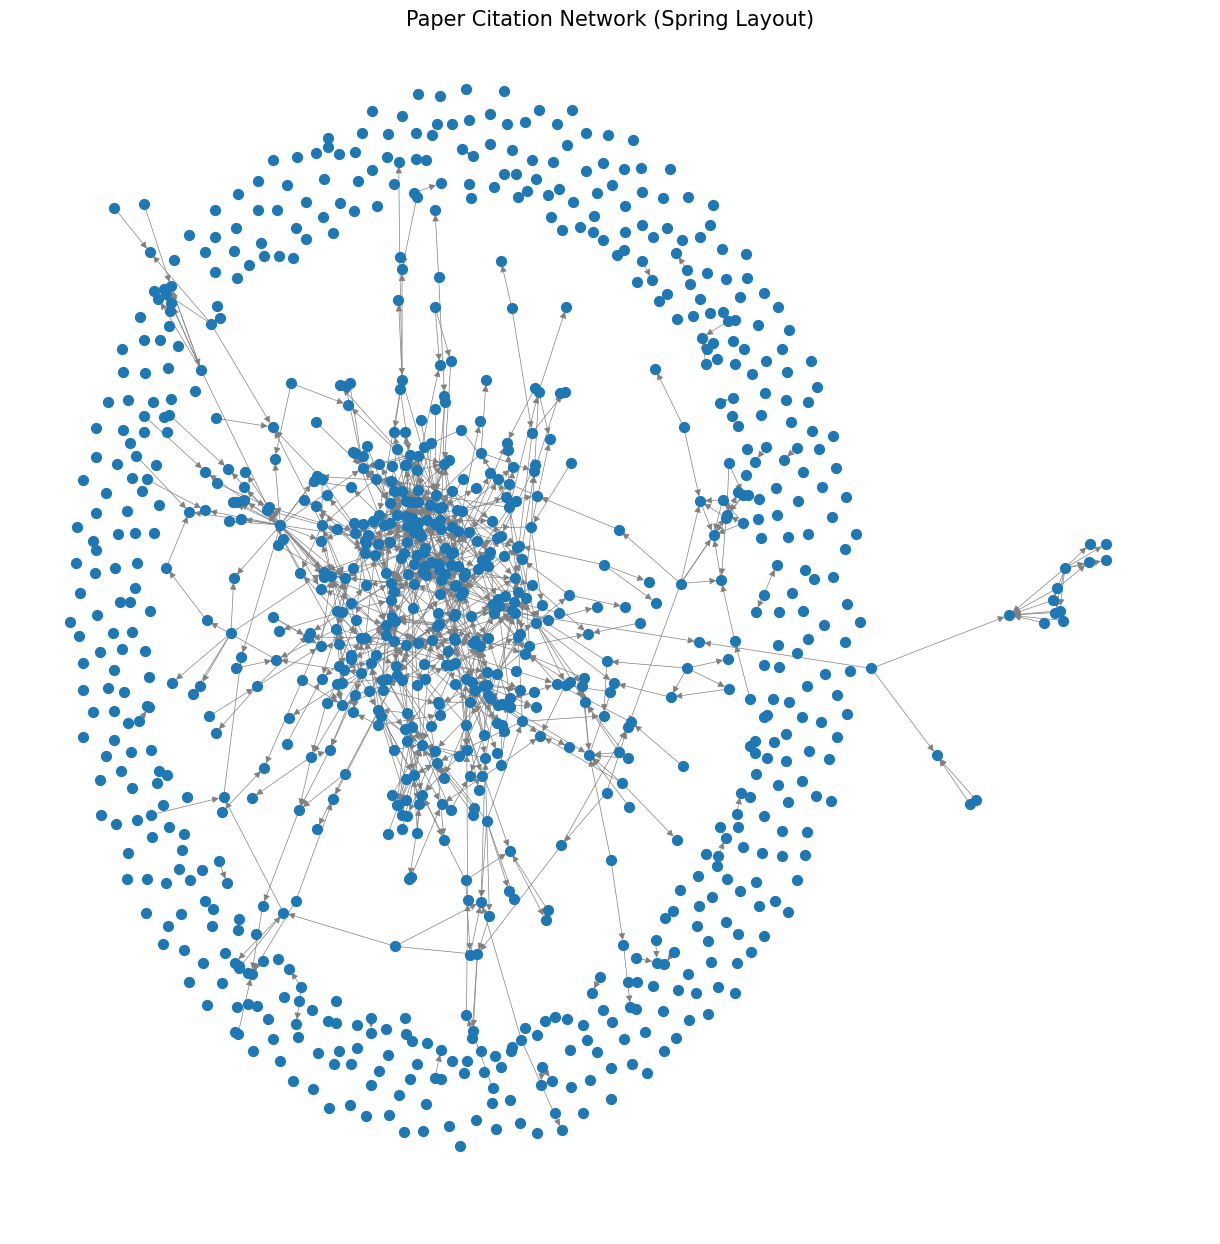

In [ ]:
if 'paper_citation_graph' in globals() and paper_citation_graph.number_of_nodes() > 0:
    plt.figure(figsize=(12, 12))
    pos = nx.spring_layout(paper_citation_graph, k=0.15, iterations=30, seed=42)
    nx.draw(
        paper_citation_graph,
        pos,
        with_labels=False,
        node_size=50,
        width=0.5,
        alpha=1,
        arrowsize=10,
        edge_color='gray',
    )
    plt.title('Paper Citation Network (Spring Layout)', size=15)
    plt.axis('off')
    plt.show()
else:
    print("Paper citation graph is not available or empty. Please ensure Objective 1 code has been run.")

Bibliographic-coupling graph nodes: 984
Bibliographic-coupling graph edges: 4337


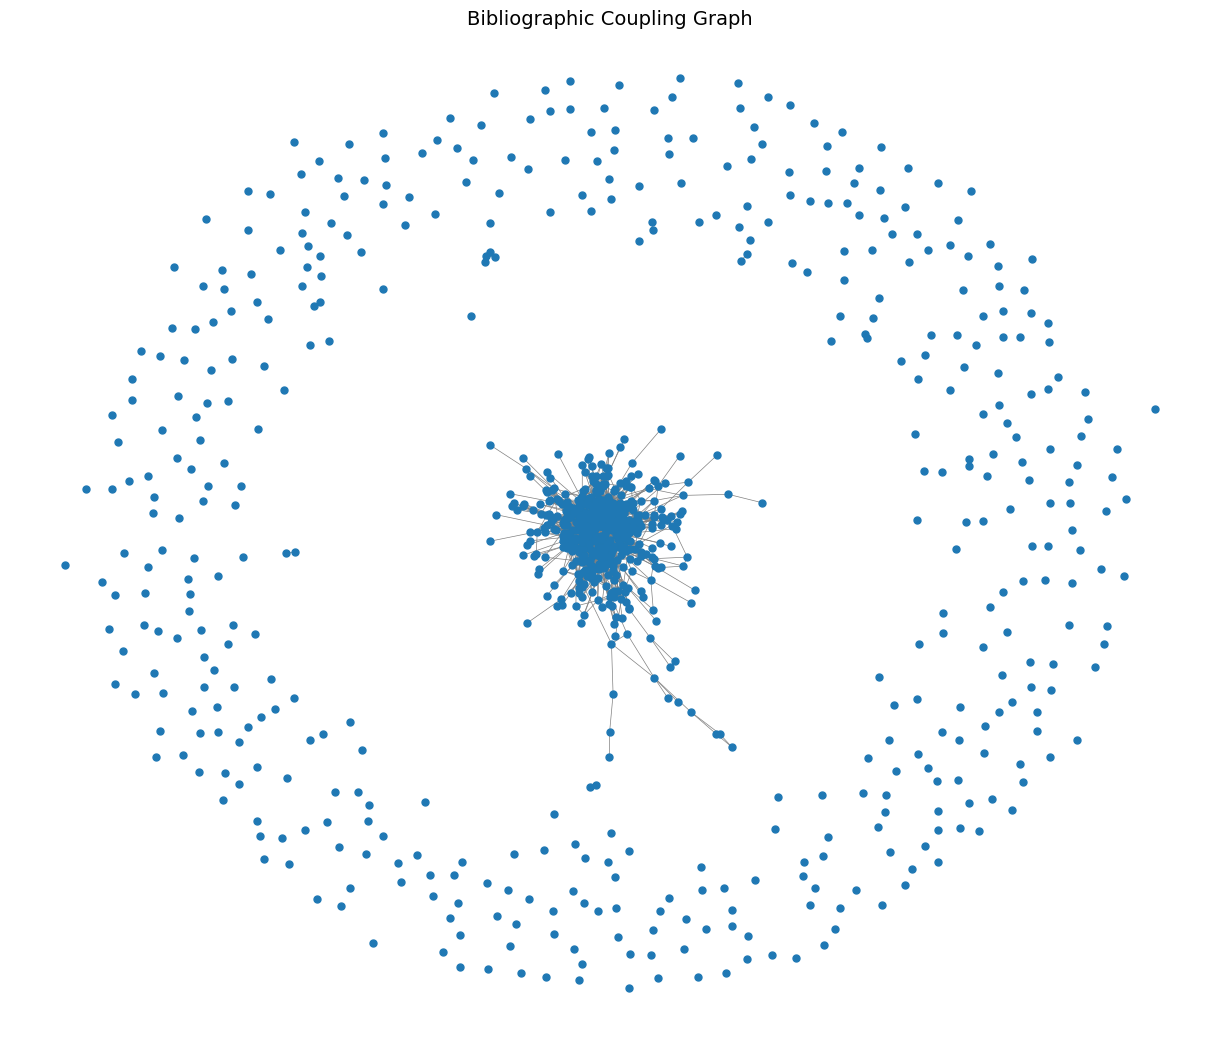

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

# Basic graph summary
print("Bibliographic-coupling graph nodes:", bibliographic_coupling_graph.number_of_nodes())
print("Bibliographic-coupling graph edges:", bibliographic_coupling_graph.number_of_edges())

# Use a spring layout for visualization
plt.figure(figsize=(12, 10))
pos = nx.spring_layout(
    bibliographic_coupling_graph,
    seed=42,
    k=0.25
)

# Extract edge weights if they exist
edge_weights = nx.get_edge_attributes(bibliographic_coupling_graph, 'weight')

# Scale edge widths for plotting
if edge_weights:
    widths = [0.3 + 0.4 * edge_weights[e] for e in bibliographic_coupling_graph.edges()]
else:
    widths = 0.5

# Draw graph
nx.draw(
    bibliographic_coupling_graph,
    pos,
    with_labels=False,
    node_size=25,
    width=0.5,
    alpha=1,
    arrowsize=10,
    edge_color='gray',
)

plt.title("Bibliographic Coupling Graph", fontsize=14)
plt.axis("off")
plt.show()

## 4.1 Corpus Overview


In [ ]:
print('Number of papers in corpus:', papers_df.shape[0])
print('Number of bibliography entries:', citations_df.shape[0])
print('Matched internal citation edges:', paper_citation_graph.number_of_edges())
print('Papers with at least one internal citation link:', int(papers_df['has_internal_citation_link'].sum()))
print('Share of papers with at least one internal citation link:', round(papers_df['has_internal_citation_link'].mean(), 3))
print('Bibliographic-coupling edges (>= 3 shared references):', bibliographic_coupling_graph.number_of_edges())


Number of papers in corpus: 984
Number of bibliography entries: 25434
Matched internal citation edges: 930
Papers with at least one internal citation link: 547
Share of papers with at least one internal citation link: 0.556
Bibliographic-coupling edges (>= 3 shared references): 4337


In [ ]:
papers_df['num_authors'] = papers_df['author_list'].apply(len)
papers_df['num_paragraphs'] = papers_df['paragraphs'].apply(
    lambda x: len(x) if isinstance(x, (list, dict)) else 0
)

display(
    papers_df[[
        'year',
        'category',
        'num_authors',
        'num_paragraphs',
        'num_citations',
        'internal_in_degree',
        'internal_out_degree',
    ]].describe(include='all')
)


,year,category,num_authors,num_paragraphs,num_citations,internal_in_degree,internal_out_degree
count,976.000000,980,984.000000,984.000000,984.000000,984.000000,984.000000
unique,NaN,36,NaN,NaN,NaN,NaN,NaN
top,NaN,articles,NaN,NaN,NaN,NaN,NaN
freq,NaN,453,NaN,NaN,NaN,NaN,NaN
mean,2011.451844,NaN,1.079268,32.596545,25.847561,0.945122,0.945122
std,8.851118,NaN,0.422916,24.612001,28.638469,1.982383,1.976730
min,1993.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2005.000000,NaN,1.000000,15.000000,0.000000,0.000000,0.000000
50%,2013.000000,NaN,1.000000,27.000000,18.000000,0.000000,0.000000
75%,2018.000000,NaN,1.000000,46.000000,41.000000,1.000000,1.000000


In [ ]:
all_keywords = []
for keywords in papers_df['keyword_list']:
    all_keywords.extend(keywords)

top_keywords_df = pd.DataFrame(
    Counter(all_keywords).most_common(15),
    columns=['keyword', 'count']
)
display(top_keywords_df)


,keyword,count
0,analysis,81
1,popular music,55
2,rhythm,48
3,form,46
4,harmony,41
5,meter,39
6,pedagogy,37
7,performance,35
8,improvisation,34
9,counterpoint,34


In [ ]:
references_per_paper = papers_df[['id', 'title_clean', 'num_citations']].rename(columns={'num_citations': 'num_references'})

print('Summary of bibliography references per paper:')
print(references_per_paper['num_references'].describe())


Summary of bibliography references per paper:
count    984.000000
mean      25.847561
std       28.638469
min        0.000000
25%        0.000000
50%       18.000000
75%       41.000000
max      208.000000
Name: num_references, dtype: float64


In [ ]:
top_internal_cited = papers_df.sort_values(
    ['internal_in_degree', 'title_clean'],
    ascending=[False, True]
)[['title_clean', 'internal_in_degree', 'year', 'author_names']].head(10)

print('Top internally cited papers in the corpus:')
display(top_internal_cited)


Top internally cited papers in the corpus:


,title_clean,internal_in_degree,year,author_names
263,"The Structure, Function, and Genesis of the Pr...",19,2011.0,Jay Summach
381,Formal Functions of Metric Dissonance in Rock ...,15,2014.0,Nicole Biamonte
256,Guitar Voicing in Pop-Rock Music: A Performanc...,13,2011.0,Timothy Koozin
83,Making Sense of Rock’s Tonal Systems,13,2004.0,Walter Everett
241,Embodying Music: Principles of the Mimetic Hyp...,12,2011.0,Arnie Cox
635,Music Theory and the White Racial Frame,12,2020.0,Philip A. Ewell
84,Parody with an Ironic Edge: Dramatic Works by ...,12,2004.0,Yayoi Uno Everett
488,Talking Back: Performer-Audience Interaction i...,12,2016.0,Paul Steinbeck
463,Film Music Themes: Analysis and Corpus Study,10,2016.0,Mark Richards
191,On the Metrical Techniques of Flow in Rap Music,10,2009.0,Kyle Adams


In [ ]:
top_references_df = pd.DataFrame(
    Counter(citations_df['citation_key']).most_common(10),
    columns=['citation_key', 'count']
)

print('Most frequently cited references across the corpus:')
display(top_references_df)


Most frequently cited references across the corpus:


,citation_key,count
0,caplin_1998,89
1,lerdahl_and_jackendoff_1983,66
2,hepokoski_and_darcy_2006,64
3,_,64
4,lewin_1987,55
5,hasty_1997,47
6,gjerdingen_2007,47
7,hatten_1994,42
8,huron_2006,41
9,krebs_1999,38


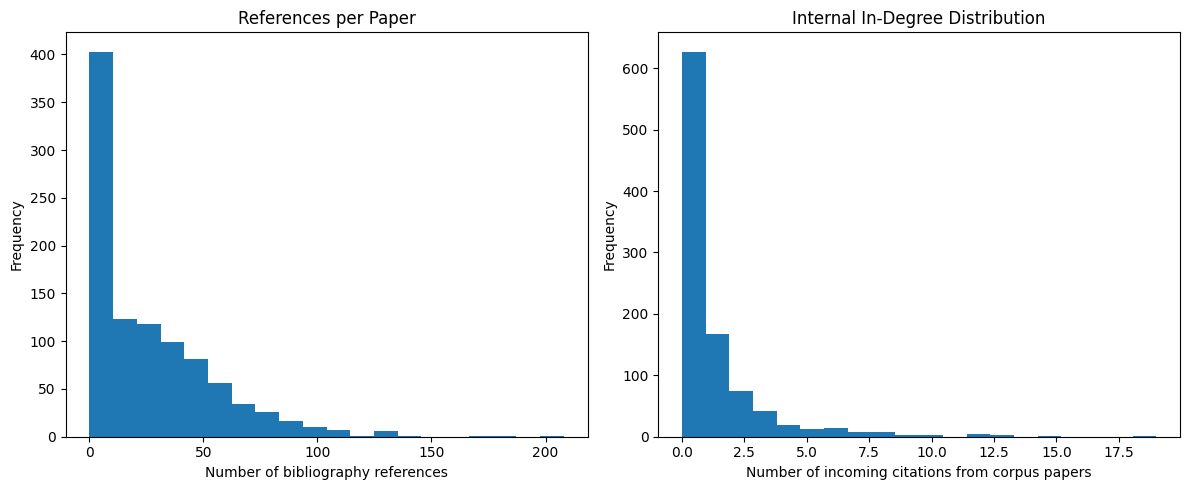

Number of unique reference keys: 16251


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(papers_df['num_citations'], bins=20)
axes[0].set_title('References per Paper')
axes[0].set_xlabel('Number of bibliography references')
axes[0].set_ylabel('Frequency')

axes[1].hist(papers_df['internal_in_degree'], bins=20)
axes[1].set_title('Internal In-Degree Distribution')
axes[1].set_xlabel('Number of incoming citations from corpus papers')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print('Number of unique reference keys:', citations_df['citation_key'].nunique())


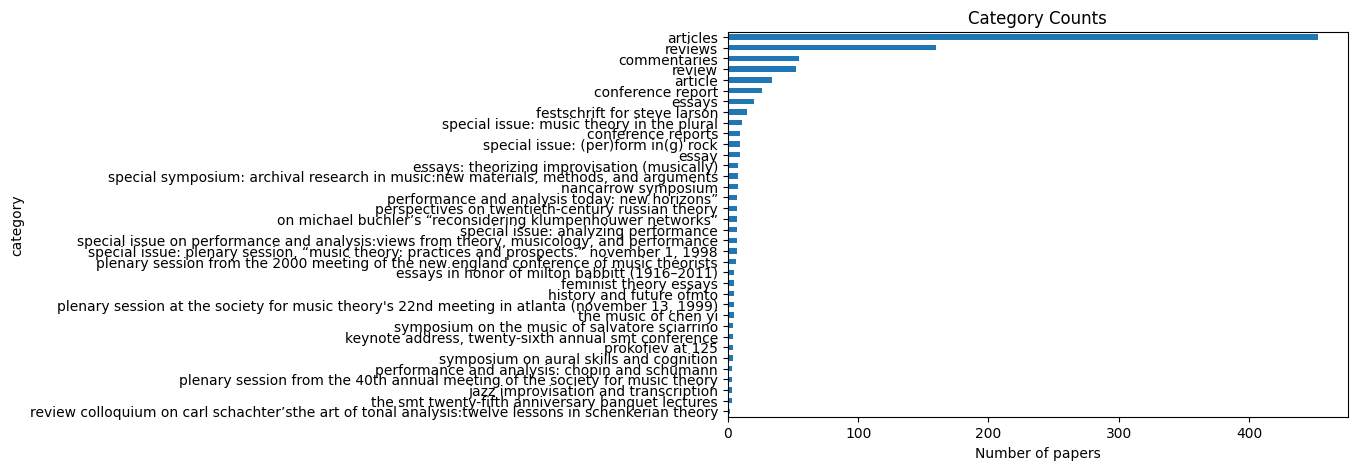

In [ ]:
papers_df['category'].value_counts().sort_values().plot(kind='barh', figsize=(7, 6))
plt.title('Category Counts', fontsize = 16, fontweight='bold')
plt.xlabel('Number of papers', fontsize = 14)
plt.show()


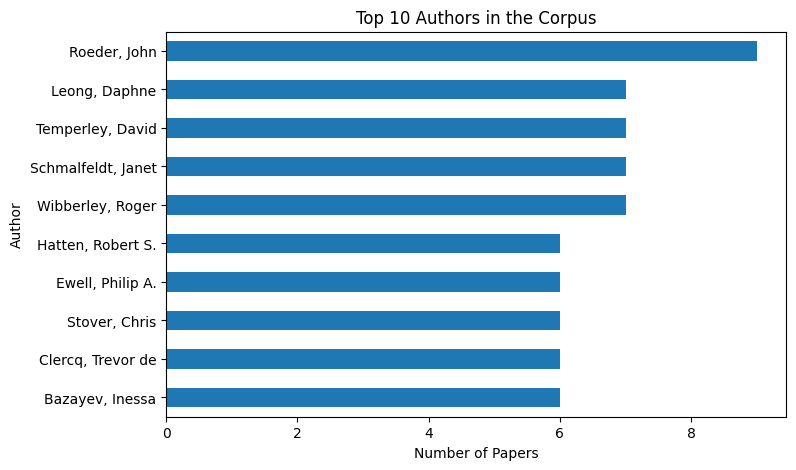

In [ ]:
authors_counts = (
    papers_df[['id', 'author_list']]
    .explode('author_list')
    .dropna(subset=['author_list'])
    .drop_duplicates()
    .groupby('author_list')
    .size()
    .sort_values(ascending=False)
    .head(10)
    .sort_values(ascending=True)
)

authors_counts.plot(kind='barh', figsize=(8, 5))
plt.xlabel('Number of Papers')
plt.ylabel('Author')
plt.title('Top 10 Authors in the Corpus')
plt.show()


## 4.2 Degree and Connectivity


### Degree

In [ ]:
in_degree_df = (
    papers_df[['id', 'title_clean', 'internal_in_degree', 'year']]
    .sort_values(by='internal_in_degree', ascending=False)
    .head(10)
    .reset_index(drop=True)
)

print('Top 10 nodes by in-degree in the paper citation graph:')
display(in_degree_df)


Top 10 nodes by in-degree in the paper citation graph:


,id,title_clean,internal_in_degree,year
0,mto.11.17.3.summach,"The Structure, Function, and Genesis of the Pr...",19,2011.0
1,mto.14.20.2.biamonte,Formal Functions of Metric Dissonance in Rock ...,15,2014.0
2,mto.04.10.4.w_everett,Making Sense of Rock’s Tonal Systems,13,2004.0
3,mto.11.17.3.koozin,Guitar Voicing in Pop-Rock Music: A Performanc...,13,2011.0
4,mto.20.26.2.ewell,Music Theory and the White Racial Frame,12,2020.0
5,mto.16.22.3.steinbeck,Talking Back: Performer-Audience Interaction i...,12,2016.0
6,mto.11.17.2.cox,Embodying Music: Principles of the Mimetic Hyp...,12,2011.0
7,mto.04.10.4.y_everett,Parody with an Ironic Edge: Dramatic Works by ...,12,2004.0
8,mto.16.22.1.richards,Film Music Themes: Analysis and Corpus Study,10,2016.0
9,mto.09.15.5.adams,On the Metrical Techniques of Flow in Rap Music,10,2009.0


In [ ]:
out_degree_df = (
    papers_df[['id', 'title_clean', 'internal_out_degree', 'year']]
    .sort_values(by='internal_out_degree', ascending=False)
    .head(10)
    .reset_index(drop=True)
)

print('Top 10 nodes by out-degree in the paper citation graph:')
display(out_degree_df)


Top 10 nodes by out-degree in the paper citation graph:


,id,title_clean,internal_out_degree,year
0,mto.14.20.1.koozin,History and Future of MTO : Evolving Content a...,27,2014.0
1,mto.24.30.3.smither,Referents in the Palimpsests of Jazz: Disentan...,13,2024.0
2,mto.21.27.4.de_clercq,The Logic of Six-Based Minor for Harmonic Anal...,12,2021.0
3,mto.24.30.2.geary,Formal Functions of Drum Patterns in Post-Mill...,12,2024.0
4,mto.22.28.4.geary,Analyzing the Beat in Metrically Consonant Pop...,11,2022.0
5,mto.22.28.3.nobile,"Teleology in Verse–Prechorus–Chorus Form, 1965...",10,2022.0
6,mto.24.30.3.cole,"Hands, Fingers, Strings, and Bows: Performance...",10,2024.0
7,mto.19.25.3.conklin,Writing Wrong Notes: Chromatic Clashes in the ...,9,2019.0
8,mto.24.30.3.short,"Three Sailors, Three Personalities: Choreomusi...",9,2024.0
9,mto.24.30.2.smith,Prosodic Dissonance,9,2024.0


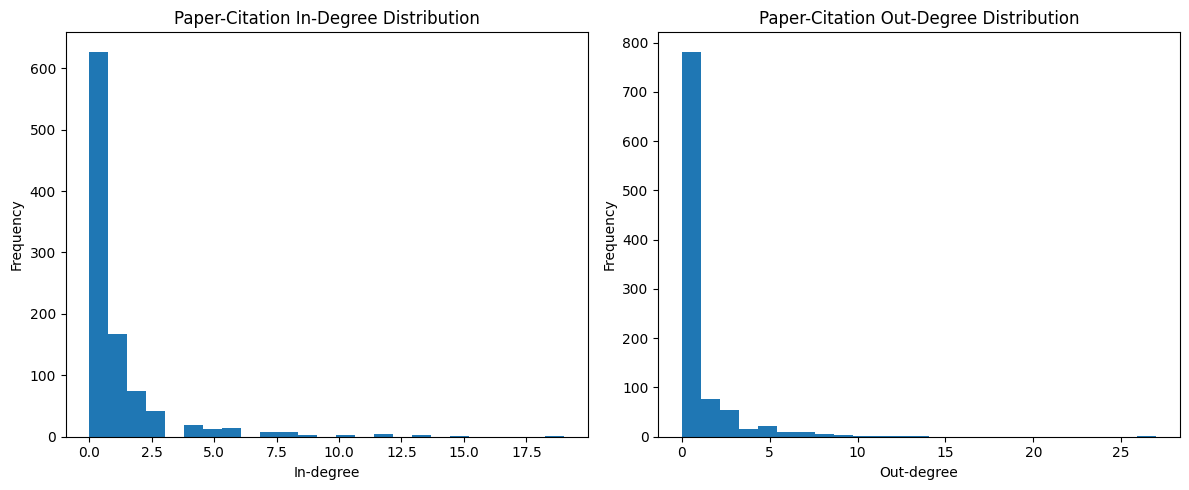

In [ ]:
in_deg = [degree for _, degree in paper_citation_graph.in_degree()]
out_deg = [degree for _, degree in paper_citation_graph.out_degree()]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(in_deg, bins=25)
axes[0].set_title('Paper-Citation In-Degree Distribution')
axes[0].set_xlabel('In-degree')
axes[0].set_ylabel('Frequency')

axes[1].hist(out_deg, bins=25)
axes[1].set_title('Paper-Citation Out-Degree Distribution')
axes[1].set_xlabel('Out-degree')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


### Density & Sparsity

In [ ]:
paper_density = nx.density(paper_citation_graph)
coupling_density = nx.density(bibliographic_coupling_graph)

print('Paper citation graph density:', paper_density)
print('Bibliographic coupling graph density:', coupling_density)


Paper citation graph density: 0.0009614668883209687
Bibliographic coupling graph density: 0.008967487945479658


### Connected Components

In [ ]:
paper_components = list(nx.weakly_connected_components(paper_citation_graph))
print('Paper citation graph weak components:', len(paper_components))
print('Largest weak component size:', len(max(paper_components, key=len)))

coupling_components = list(nx.connected_components(bibliographic_coupling_graph))
print('Bibliographic coupling graph connected components:', len(coupling_components))
print('Largest coupling component size:', len(max(coupling_components, key=len)))


Paper citation graph weak components: 463
Largest weak component size: 490
Bibliographic coupling graph connected components: 438
Largest coupling component size: 537


## 4.3 Temporal Analysis


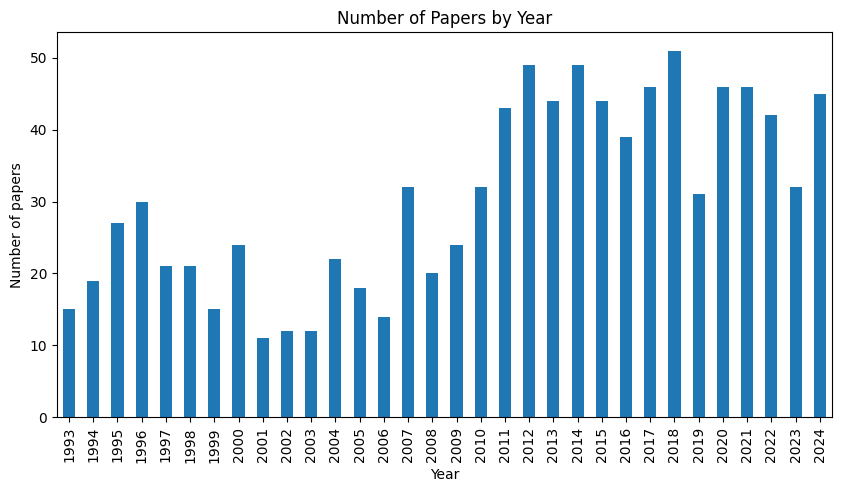

In [ ]:
papers_by_year = papers_df['year'].dropna().astype(int).value_counts().sort_index()
papers_by_year.plot(kind='bar', figsize=(7, 6))
plt.title('Number of Papers by Year', fontsize = 16, fontweight='bold')
plt.xlabel('Year', fontsize = 14)
plt.ylabel('Number of papers', fontsize = 14)
plt.show()


,num_papers,bibliography_references,internal_citations_received,internal_citations_made
year,,,,
2015,44,1678,44,38
2016,39,1293,67,56
2017,46,1853,64,59
2018,51,1763,21,48
2019,31,1270,24,61
2020,46,2151,42,71
2021,46,2294,24,95
2022,42,2047,27,118
2023,32,1566,7,59


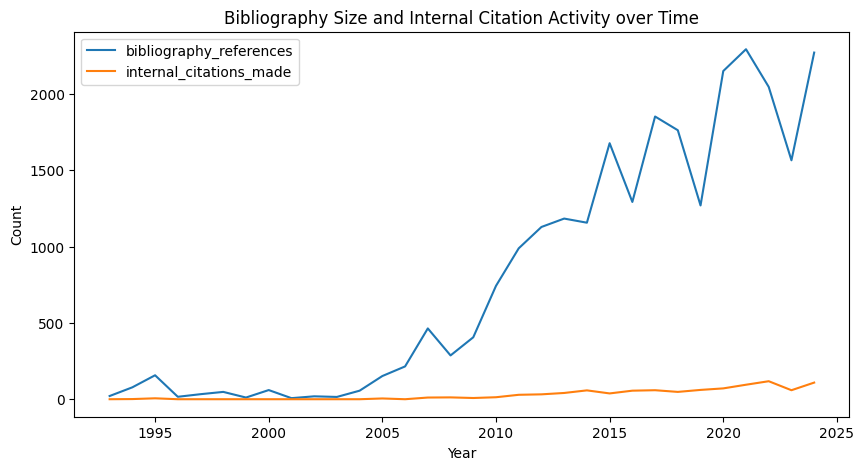

In [ ]:
yearly_summary = (
    papers_df.dropna(subset=['year'])
    .assign(year=lambda df: df['year'].astype(int))
    .groupby('year')
    .agg(
        num_papers=('id', 'count'),
        bibliography_references=('num_citations', 'sum'),
        internal_citations_received=('internal_in_degree', 'sum'),
        internal_citations_made=('internal_out_degree', 'sum'),
    )
)

display(yearly_summary.tail(10))

yearly_summary[['bibliography_references', 'internal_citations_made']].plot(figsize=(10, 5))
plt.title('Bibliography Size and Internal Citation Activity over Time')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()


# **5. Objective 2: Identify Thematic Communities in the Literature**


## 5.1 Shared Setup for Community Detection

In [ ]:
def flatten_counter(series, top_n=10):
    values = []
    for item in series:
        if isinstance(item, list):
            values.extend(item)
    return Counter(values).most_common(top_n)


def extract_italicized_works(text):
    if not isinstance(text, str):
        return []
    return [clean_text(match) for match in re.findall(r'<i>(.*?)</i>', text)]


def extract_composer_or_work_terms(row):
    candidates = []
    if isinstance(row.get('keyword_list'), list):
        candidates.extend([kw for kw in row['keyword_list'] if isinstance(kw, str) and kw[:1].isupper()])
    for field in (row.get('title', ''), row.get('abstract', '')):
        candidates.extend(extract_italicized_works(field))
    return [term for term in candidates if term]


def summarize_partition(dataframe, partition_column, strength_lookup=None, top_n=10, label_prefix='Group'):
    summary_rows = []
    grouped = dataframe.dropna(subset=[partition_column]).groupby(partition_column)

    for group_id, group_papers in grouped:
        group_papers = group_papers.copy()
        if strength_lookup is not None:
            group_papers['group_strength'] = group_papers['id'].map(strength_lookup).fillna(0)
            sort_columns = ['group_strength', 'internal_in_degree']
        else:
            sort_columns = ['internal_in_degree']

        representative_papers = (
            group_papers
            .sort_values(sort_columns, ascending=False)
            [['title_clean', 'author_names', 'year']]
            .head(3)
            .to_dict('records')
        )

        top_refs = Counter(citations_df.loc[citations_df['paper_id'].isin(group_papers['id']), 'citation_key']).most_common(6)
        top_authors = Counter(author for authors in group_papers['author_list'] for author in authors).most_common(5)

        summary_rows.append({
            'group_id': int(group_id),
            'group_label': f'{label_prefix} {int(group_id)}',
            'num_papers': len(group_papers),
            'top_keywords': flatten_counter(group_papers['keyword_list'], top_n=8),
            'top_references': top_refs,
            'top_authors': top_authors,
            'composer_or_work_terms': flatten_counter(group_papers['composer_or_work_terms'], top_n=6),
            'representative_papers': representative_papers,
        })

    return pd.DataFrame(summary_rows).sort_values('num_papers', ascending=False).head(top_n).reset_index(drop=True)


In [ ]:
papers_df['composer_or_work_terms'] = papers_df.apply(extract_composer_or_work_terms, axis=1)
community_graph = bibliographic_coupling_graph.subgraph(
    [node for node, degree in bibliographic_coupling_graph.degree() if degree > 0]
).copy()
community_graph_strength = dict(community_graph.degree(weight='weight'))

print(f'Community-detection graph nodes: {community_graph.number_of_nodes():,}')
print(f'Community-detection graph edges: {community_graph.number_of_edges():,}')
print(f'Community-detection graph density: {nx.density(community_graph):.4f}')


Community-detection graph nodes: 555
Community-detection graph edges: 4,337
Community-detection graph density: 0.0282


## 5.2 Stochastic Block Model (SBM) with NetworkX

This section implements a classical undirected SBM in NetworkX. Following the assignment idea, the project does not fix the number of blocks in advance. Instead, it searches over a data-driven range of candidate block counts and chooses the model with the best BIC score.


### 5.2.1 SBM Helper Functions


In [ ]:
def build_sbm_backbone_graph(
    G,
    quantiles=(0.75, 0.60, 0.50),
    minimum_weight=3,
    minimum_component_share=0.35,
):
    weights = [data.get('weight', 1) for _, _, data in G.edges(data=True)]
    if not weights:
        raise ValueError('The bibliographic-coupling graph has no edges, so SBM cannot be estimated.')

    n_total = max(G.number_of_nodes(), 1)
    chosen_graph = None
    chosen_cutoff = None

    for quantile in quantiles:
        cutoff = max(minimum_weight, int(np.ceil(np.quantile(weights, quantile))))
        H = nx.Graph()
        H.add_nodes_from(G.nodes(data=True))
        for u, v, data in G.edges(data=True):
            if data.get('weight', 1) >= cutoff:
                H.add_edge(u, v, **data)

        H.remove_nodes_from(list(nx.isolates(H)))
        if H.number_of_edges() == 0:
            continue

        component_nodes = max(nx.connected_components(H), key=len)
        component_graph = H.subgraph(component_nodes).copy()
        if component_graph.number_of_nodes() >= max(25, int(minimum_component_share * n_total)):
            chosen_graph = component_graph
            chosen_cutoff = cutoff
            break

    if chosen_graph is None:
        cutoff = max(minimum_weight, int(np.ceil(np.median(weights))))
        H = nx.Graph()
        H.add_nodes_from(G.nodes(data=True))
        for u, v, data in G.edges(data=True):
            if data.get('weight', 1) >= cutoff:
                H.add_edge(u, v, **data)
        H.remove_nodes_from(list(nx.isolates(H)))
        if H.number_of_edges() == 0:
            raise ValueError('No SBM backbone could be formed from the coupling graph.')
        component_nodes = max(nx.connected_components(H), key=len)
        chosen_graph = H.subgraph(component_nodes).copy()
        chosen_cutoff = cutoff

    return chosen_graph, chosen_cutoff


def remap_partition(labels):
    unique_labels = sorted(set(int(label) for label in labels))
    label_map = {label: idx for idx, label in enumerate(unique_labels)}
    return np.array([label_map[int(label)] for label in labels], dtype=int)


def choose_sbm_block_candidates(G, min_blocks=2):
    n = G.number_of_nodes()
    if n < 4:
        return [2]

    # We let graph size determine the search range rather than fixing B by hand.
    dynamic_cap = int(np.ceil(np.sqrt(n)))
    upper = min(dynamic_cap, n - 1)
    return list(range(min_blocks, upper + 1))


In [ ]:
def sbm_block_statistics(G, labels, node_order=None):
    if node_order is None:
        node_order = list(G.nodes())

    labels = np.asarray(labels, dtype=int)
    if len(labels) != len(node_order):
        raise ValueError('Partition vector length must match the number of nodes in node_order.')

    B = int(labels.max()) + 1
    sizes = np.bincount(labels, minlength=B)
    node_to_idx = {node: idx for idx, node in enumerate(node_order)}

    E = np.zeros((B, B), dtype=float)
    for u, v in G.edges():
        bu = labels[node_to_idx[u]]
        bv = labels[node_to_idx[v]]
        E[bu, bv] += 1
        if bu != bv:
            E[bv, bu] += 1

    N = np.zeros((B, B), dtype=float)
    for k in range(B):
        for l in range(B):
            if k == l:
                N[k, l] = comb(int(sizes[k]), 2) if sizes[k] >= 2 else 0
            else:
                N[k, l] = int(sizes[k]) * int(sizes[l])

    M = np.divide(E, N, out=np.zeros_like(E), where=N > 0)
    return E, N, M, sizes


def sbm_log_likelihood(G, labels, node_order=None, epsilon=1e-9):
    E, N, M, sizes = sbm_block_statistics(G, labels, node_order=node_order)
    probabilities = np.clip(M, epsilon, 1 - epsilon)

    log_likelihood = 0.0
    B = probabilities.shape[0]
    for k in range(B):
        for l in range(k + 1):
            if N[k, l] <= 0:
                continue
            log_likelihood += (
                E[k, l] * np.log(probabilities[k, l])
                + (N[k, l] - E[k, l]) * np.log(1 - probabilities[k, l])
            )

    return log_likelihood, probabilities, E, N, sizes


In [ ]:
def random_partition(n_nodes, n_blocks, rng):
    labels = np.arange(n_nodes) % n_blocks
    rng.shuffle(labels)
    return labels.astype(int)


def optimize_sbm_partition(
    G,
    n_blocks,
    iterations=1200,
    restarts=4,
    changes_per_step=2,
    cooling_slowness=250,
    seed=42,
):
    node_order = list(G.nodes())
    n_nodes = len(node_order)
    rng = np.random.default_rng(seed)

    best_labels = None
    best_log_likelihood = -np.inf
    best_trace = None
    best_probability_matrix = None

    for _ in range(restarts):
        labels = random_partition(n_nodes, n_blocks, rng)
        current_log_likelihood, probability_matrix, _, _, _ = sbm_log_likelihood(G, labels, node_order=node_order)
        trace = [current_log_likelihood]

        best_restart_labels = labels.copy()
        best_restart_ll = current_log_likelihood
        best_restart_probability_matrix = probability_matrix.copy()

        for step in range(iterations):
            temperature = (1 + cooling_slowness) / (step + 1 + cooling_slowness)
            candidate = labels.copy()
            changed_positions = rng.choice(n_nodes, size=min(changes_per_step, n_nodes), replace=False)
            for idx in changed_positions:
                candidate[idx] = int(rng.integers(n_blocks))

            if len(set(candidate)) < 2:
                trace.append(current_log_likelihood)
                continue

            candidate_log_likelihood, candidate_probability_matrix, _, _, _ = sbm_log_likelihood(
                G,
                candidate,
                node_order=node_order,
            )

            accept = candidate_log_likelihood >= current_log_likelihood
            if not accept:
                accept = rng.random() < np.exp((candidate_log_likelihood - current_log_likelihood) / max(temperature, 1e-12))

            if accept:
                labels = candidate
                current_log_likelihood = candidate_log_likelihood
                probability_matrix = candidate_probability_matrix
                if current_log_likelihood > best_restart_ll:
                    best_restart_labels = labels.copy()
                    best_restart_ll = current_log_likelihood
                    best_restart_probability_matrix = probability_matrix.copy()

            trace.append(current_log_likelihood)

        if best_restart_ll > best_log_likelihood:
            best_labels = remap_partition(best_restart_labels)
            best_log_likelihood = best_restart_ll
            best_trace = trace
            best_probability_matrix = best_restart_probability_matrix

    return {
        'labels': best_labels,
        'node_order': node_order,
        'log_likelihood': best_log_likelihood,
        'probability_matrix': best_probability_matrix,
        'trace': best_trace,
    }


### 5.2.2 Fit the SBM and Select the Number of Blocks


In [ ]:
sbm_graph, sbm_weight_cutoff = build_sbm_backbone_graph(community_graph)
sbm_candidate_blocks = choose_sbm_block_candidates(sbm_graph)
sbm_search_results = []

for n_blocks in sbm_candidate_blocks:
    result = optimize_sbm_partition(
        sbm_graph,
        n_blocks=n_blocks,
        iterations=900,
        restarts=3,
        changes_per_step=2,
        cooling_slowness=200,
        seed=42 + n_blocks,
    )
    n_pairs = max(comb(sbm_graph.number_of_nodes(), 2), 1)
    num_parameters = max(n_blocks * (n_blocks + 1) // 2, 1)
    bic = -2 * result['log_likelihood'] + num_parameters * np.log(n_pairs)
    sbm_search_results.append({
        'n_blocks': n_blocks,
        'log_likelihood': result['log_likelihood'],
        'bic': bic,
        'num_nodes': sbm_graph.number_of_nodes(),
        'num_edges': sbm_graph.number_of_edges(),
        'result': result,
    })

sbm_model_selection_df = pd.DataFrame([
    {
        'n_blocks': row['n_blocks'],
        'log_likelihood': row['log_likelihood'],
        'bic': row['bic'],
        'num_nodes': row['num_nodes'],
        'num_edges': row['num_edges'],
    }
    for row in sbm_search_results
]).sort_values('bic').reset_index(drop=True)

best_sbm_row = sbm_search_results[int(np.argmin([row['bic'] for row in sbm_search_results]))]
best_sbm_result = best_sbm_row['result']
sbm_node_order = best_sbm_result['node_order']
sbm_labels = best_sbm_result['labels']
sbm_partition = {node: int(label) for node, label in zip(sbm_node_order, sbm_labels)}
papers_df['sbm_block_id'] = papers_df['id'].map(sbm_partition)

sbm_log_likelihood_value, sbm_probability_matrix, sbm_E, sbm_N, sbm_block_sizes = sbm_log_likelihood(
    sbm_graph,
    sbm_labels,
    node_order=sbm_node_order,
)

print(f'SBM backbone nodes: {sbm_graph.number_of_nodes():,}')
print(f'SBM backbone edges: {sbm_graph.number_of_edges():,}')
print(f'Backbone shared-reference cutoff: >= {sbm_weight_cutoff}')
print(f'Data-driven candidate block counts: {sbm_candidate_blocks}')
print(f'Selected number of SBM blocks (lowest BIC): {best_sbm_row["n_blocks"]}')
print(f'SBM log-likelihood: {sbm_log_likelihood_value:.1f}')
display(sbm_model_selection_df)


SBM backbone nodes: 346
SBM backbone edges: 1,234
Backbone shared-reference cutoff: >= 5
Data-driven candidate block counts: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Selected number of SBM blocks (lowest BIC): 6
SBM log-likelihood: -5203.7


,n_blocks,log_likelihood,bic,num_nodes,num_edges
0,6,-5203.739949,10638.413455,346,1234
1,4,-5294.344701,10698.657763,346,1234
2,3,-5316.421249,10698.823514,346,1234
3,5,-5272.341362,10709.635265,346,1234
4,2,-5372.344342,10777.679193,346,1234
5,7,-5252.840814,10813.593036,346,1234
6,8,-5213.093301,10822.072698,346,1234
7,9,-5189.286157,10873.429934,346,1234
8,10,-5198.323863,11001.473706,346,1234
9,11,-5206.810329,11139.411835,346,1234


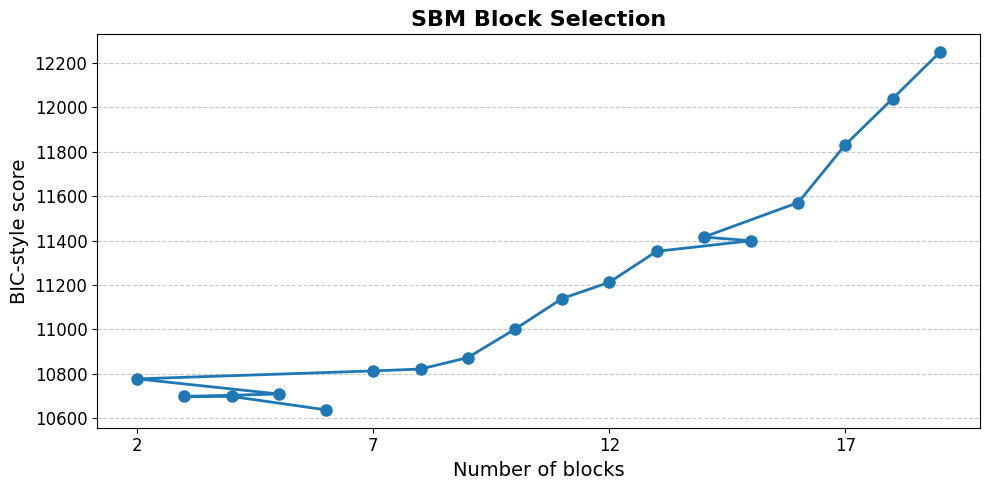

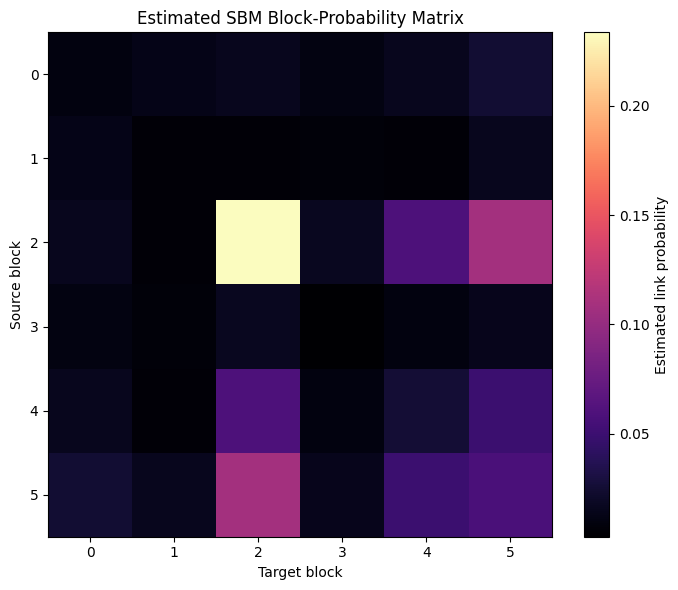

In [ ]:
plt.figure(figsize=(10, 5), dpi=100)
plt.plot(sbm_model_selection_df['n_blocks'], sbm_model_selection_df['bic'],
         marker='o', markersize=8, linewidth=2)

plt.title('SBM Block Selection', fontsize=16, fontweight='bold')
plt.xlabel('Number of blocks', fontsize=14)
plt.ylabel('BIC-style score', fontsize=14)
ticks = range(min(sbm_model_selection_df['n_blocks']),
              max(sbm_model_selection_df['n_blocks']) + 1, 5)
plt.xticks(ticks, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7) # Optional: adds horizontal guide lines
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 6))
plt.imshow(sbm_probability_matrix, cmap='magma', aspect='auto')
plt.colorbar(label='Estimated link probability')
plt.xticks(range(sbm_probability_matrix.shape[0]), range(sbm_probability_matrix.shape[0]))
plt.yticks(range(sbm_probability_matrix.shape[0]), range(sbm_probability_matrix.shape[0]))
plt.xlabel('Target block')
plt.ylabel('Source block')
plt.title('Estimated SBM Block-Probability Matrix')
plt.tight_layout()
plt.show()


### 5.2.3 Interpret the SBM Blocks


In [ ]:
sbm_block_strength = dict(sbm_graph.degree())
sbm_block_summaries = []

for sbm_block_id, block_papers in papers_df.dropna(subset=['sbm_block_id']).groupby('sbm_block_id'):
    block_papers = block_papers.copy()
    block_papers['sbm_block_strength'] = block_papers['id'].map(sbm_block_strength).fillna(0)

    representative_papers = (
        block_papers
        .sort_values(['sbm_block_strength', 'internal_in_degree'], ascending=False)
        [['title_clean', 'author_names', 'year']]
        .head(3)
        .to_dict('records')
    )

    top_refs = Counter(
        citations_df.loc[citations_df['paper_id'].isin(block_papers['id']), 'citation_key']
    ).most_common(6)

    top_authors = Counter(
        author
        for authors in block_papers['author_list']
        for author in authors
    ).most_common(5)

    sbm_block_summaries.append({
        'sbm_block_id': int(sbm_block_id),
        'num_papers': len(block_papers),
        'top_keywords': flatten_counter(block_papers['keyword_list'], top_n=8),
        'top_references': top_refs,
        'top_authors': top_authors,
        'composer_or_work_terms': flatten_counter(block_papers['composer_or_work_terms'], top_n=6),
        'representative_papers': representative_papers,
    })

sbm_block_summary_df = (
    pd.DataFrame(sbm_block_summaries)
    .sort_values('num_papers', ascending=False)
    .reset_index(drop=True)
)

display(sbm_block_summary_df.head(10))


,sbm_block_id,num_papers,top_keywords,top_references,top_authors,composer_or_work_terms,representative_papers
0,3,81,"[(popular music, 6), (rhythm, 5), (analysis, 4...","[(rothstein_1989, 12), (lerdahl_and_jackendoff...","[(Ewell, Philip A., 3), (Tymoczko, Dmitri, 2),...","[(J. S. Bach, 4), (Ravel, 3), (Russian music, ...",[{'title_clean': 'Recapitulatory Compressions ...
1,1,78,"[(analysis, 7), (form, 5), (improvisation, 5),...","[(caplin_1998, 12), (gjerdingen_2007, 8), (hep...","[(Benadon, Fernando, 2), (Murphy, Scott, 2), (...","[(Schenker, 4), (Ravel, 3), (Bartók, 2), (Guba...",[{'title_clean': 'On Duration and Developing V...
2,0,54,"[(rhythm, 6), (performance, 4), (improvisation...","[(hasty_1997, 9), (hatten_1994, 7), (caplin_19...","[(Stover, Chris, 2), (Zeller, Matthew, 2), (Ca...","[(Schoenberg, 4), (Klangfarbenmelodie, 4), (Ch...",[{'title_clean': 'Melodic Organization and Seq...
3,4,53,"[(form, 10), (rhythm, 6), (meter, 6), (improvi...","[(caplin_1998, 18), (hepokoski_and_darcy_2006,...","[(Hatten, Robert S., 2), (Benadon, Fernando, 1...","[(Schenker, 2), (Mozart, 2), (Chromaticism, 2)...",[{'title_clean': 'Brahmsian Articulation: Ambi...
4,2,43,"[(popular music, 15), (form, 10), (harmony, 7)...","[(stephenson_2002, 20), (caplin_1998, 18), (le...","[(Clercq, Trevor de, 3), (Duinker, Ben, 3), (T...","[(Schenkerian analysis, 3), (Mozart, 2), (Lewi...",[{'title_clean': 'Formal Functions of Metric D...
5,5,37,"[(popular music, 5), (transformational theory,...","[(caplin_1998, 9), (hepokoski_and_darcy_2006, ...","[(Polak, Rainer, 2), (Butterfield, Matthew W.,...","[(Formenlehre, 3), (Lewin, 2), (Klumpenhouwer ...",[{'title_clean': 'Extending the Parallel Multi...


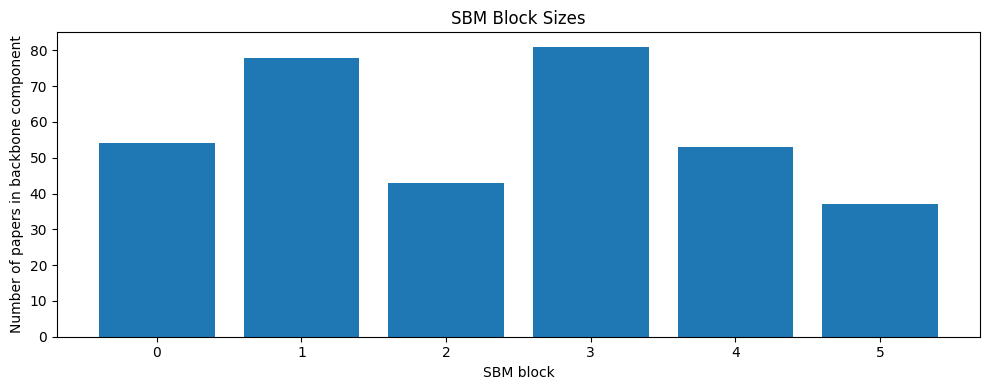

In [ ]:
sbm_block_size_df = (
    papers_df['sbm_block_id']
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
    .rename_axis('sbm_block_id')
    .reset_index(name='num_papers')
)

plt.figure(figsize=(10, 4))
plt.bar(sbm_block_size_df['sbm_block_id'].astype(str), sbm_block_size_df['num_papers'])
plt.title('SBM Block Sizes')
plt.xlabel('SBM block')
plt.ylabel('Number of papers in backbone component')
plt.tight_layout()
plt.show()


## 5.3 Spectral / Embedding-Based Method

Builds a low-dimensional embedding of the weighted bibliographic-coupling graph from the normalized graph Laplacian and then clusters papers in that embedding space.

### 5.3.1 Build the Weighted Adjacency and Laplacian


In [ ]:
from sklearn.preprocessing import normalize

spectral_nodes = list(community_graph.nodes())
spectral_node_to_idx = {node: i for i, node in enumerate(spectral_nodes)}

spectral_adjacency = nx.to_numpy_array(
    community_graph,
    nodelist=spectral_nodes,
    weight='weight',
    dtype=float,
)
spectral_adjacency = 0.5 * (spectral_adjacency + spectral_adjacency.T)

if spectral_adjacency.shape[0] < 3:
    raise ValueError('community_graph is too small for spectral embedding.')


In [ ]:
def laplacian_from_adjacency(adjacency_matrix, eps=1e-12):
    degrees = adjacency_matrix.sum(axis=1)
    degrees = np.diag(degrees)
    laplacian = degrees - adjacency_matrix
    return laplacian, degrees


def laplacian_eigenmap_embedding(adjacency_matrix, n_components):
    laplacian, degrees = laplacian_from_adjacency(adjacency_matrix)
    eigenvalues, eigenvectors = eigh(laplacian)
    order = np.argsort(eigenvalues)
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    nontrivial = np.where(eigenvalues > 1e-9)[0]
    if len(nontrivial) < n_components:
        raise ValueError('Not enough non-trivial eigenvectors are available for the requested embedding dimension.')

    selected = nontrivial[:n_components]
    embedding = eigenvectors[:, selected]
    embedding = normalize(embedding, norm='l2')

    return embedding, eigenvalues, eigenvectors, degrees


### 5.3.2 Choose the Number of Communities with an Eigengap Rule


In [ ]:
def choose_spectral_k(eigenvalues, k_min=2, k_max=12):
    upper = min(k_max, len(eigenvalues) - 2)
    rows = []
    for k in range(k_min, upper + 1):
        eigengap = float(eigenvalues[k] - eigenvalues[k - 1])
        rows.append({
            'k': k,
            'lambda_k_minus_1': float(eigenvalues[k - 1]),
            'lambda_k': float(eigenvalues[k]),
            'eigengap': eigengap,
        })

    diagnostics = pd.DataFrame(rows)
    if diagnostics.empty:
        raise ValueError('Unable to evaluate an eigengap-based cluster-count search on this graph.')

    best_row = diagnostics.sort_values(['eigengap', 'k'], ascending=[False, True]).iloc[0]
    return int(best_row['k']), diagnostics.sort_values('k').reset_index(drop=True)


In [ ]:
spectral_preview_embedding, spectral_eigenvalues, spectral_eigenvectors, spectral_degrees = laplacian_eigenmap_embedding(
    spectral_adjacency,
    n_components=min(15, spectral_adjacency.shape[0] - 1),
)
spectral_num_clusters, spectral_k_diagnostics = choose_spectral_k(
    spectral_eigenvalues,
    k_min=2,
    k_max=min(12, spectral_adjacency.shape[0] - 2),
)

print(f'Selected number of spectral communities (largest eigengap): {spectral_num_clusters}')
display(spectral_k_diagnostics)


Selected number of spectral communities (largest eigengap): 11


,k,lambda_k_minus_1,lambda_k,eigengap
0,2,-1.542315e-14,-5.488853e-15,9.934302e-15
1,3,-5.488853e-15,-3.597573e-15,1.891279e-15
2,4,-3.597573e-15,-2.231538e-15,1.366035e-15
3,5,-2.231538e-15,-1.438079e-15,7.934587e-16
4,6,-1.438079e-15,2.148864e-15,3.586943e-15
5,7,2.148864e-15,5.240461e-15,3.091597e-15
6,8,5.240461e-15,1.096150e-14,5.721034e-15
7,9,1.096150e-14,2.533000e-01,2.533000e-01
8,10,2.533000e-01,5.247538e-01,2.714538e-01
9,11,5.247538e-01,9.711367e-01,4.463829e-01


### 5.3.3 Compute the Laplacian-Eigenmap Embedding and Cluster the Papers


In [ ]:
spectral_embedding, spectral_eigenvalues, spectral_eigenvectors, spectral_degrees = laplacian_eigenmap_embedding(
    spectral_adjacency,
    n_components=spectral_num_clusters,
)

spectral_kmeans = KMeans(
    n_clusters=spectral_num_clusters,
    n_init=100,
    random_state=42,
)
spectral_labels = spectral_kmeans.fit_predict(spectral_embedding)

spectral_community_lookup = {
    node: int(label)
    for node, label in zip(spectral_nodes, spectral_labels)
}

spectral_communities = []
for cid in sorted(set(spectral_labels)):
    spectral_communities.append(
        {node for node, label in spectral_community_lookup.items() if label == cid}
    )

papers_df['spectral_community_id'] = papers_df['id'].map(spectral_community_lookup)


In [ ]:
spectral_community_sizes = (
    papers_df['spectral_community_id']
    .dropna()
    .astype(int)
    .value_counts()
    .sort_values(ascending=False)
    .rename_axis('spectral_community_id')
    .reset_index(name='num_papers')
)

print(f'Spectral communities detected: {len(spectral_communities)}')
print(f'KMeans inertia in spectral embedding: {spectral_kmeans.inertia_:.3f}')
display(spectral_community_sizes.head(10))


Spectral communities detected: 11
KMeans inertia in spectral embedding: 45.797


,spectral_community_id,num_papers
0,1,365
1,9,63
2,3,23
3,0,21
4,2,17
5,5,17
6,4,15
7,8,11
8,6,10
9,7,7


### 5.3.4 Visualize the Spectral Method


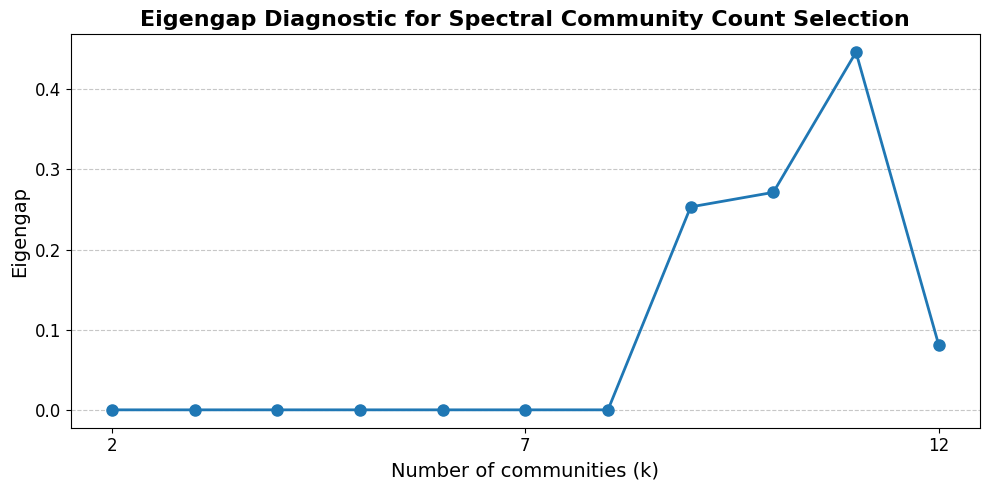

In [ ]:
plt.figure(figsize=(10, 5), dpi=100)

plt.plot(spectral_k_diagnostics['k'], spectral_k_diagnostics['eigengap'],
         marker='o', markersize=8, linewidth=2)
plt.title('Eigengap Diagnostic for Spectral Community Count Selection', fontsize=16, fontweight='bold')
plt.xlabel('Number of communities (k)', fontsize=14)
plt.ylabel('Eigengap', fontsize=14)
ticks = range(min(spectral_k_diagnostics['k']), max(spectral_k_diagnostics['k']) + 1, 5)
plt.xticks(ticks, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

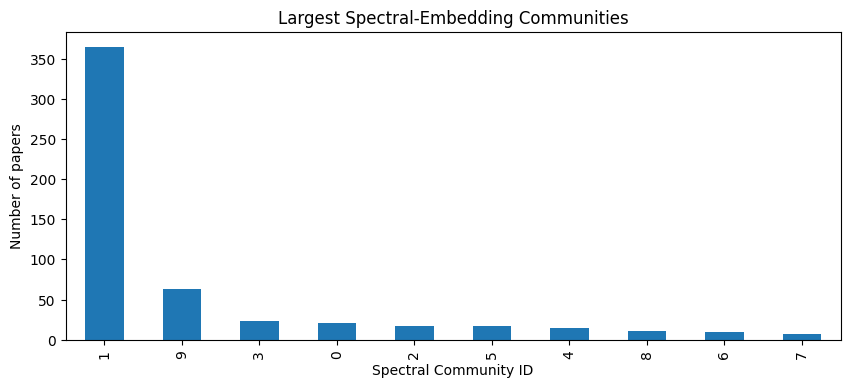

In [ ]:
if len(spectral_community_sizes):
    spectral_community_sizes.head(10).plot(
        kind='bar',
        x='spectral_community_id',
        y='num_papers',
        figsize=(10, 4),
        legend=False,
    )
    plt.title('Largest Spectral-Embedding Communities')
    plt.xlabel('Spectral Community ID')
    plt.ylabel('Number of papers')
    plt.show()


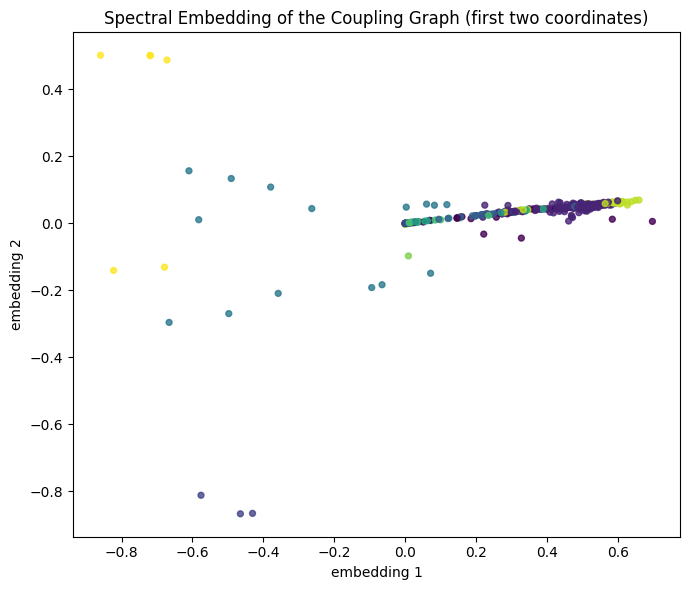

In [ ]:
if spectral_embedding.shape[1] >= 2:
    plt.figure(figsize=(7, 6))
    plt.scatter(
        spectral_embedding[:, 0],
        spectral_embedding[:, 1],
        c=spectral_labels,
        s=18,
        alpha=0.8,
    )
    plt.title('Spectral Embedding of the Coupling Graph (first two coordinates)')
    plt.xlabel('embedding 1')
    plt.ylabel('embedding 2')
    plt.tight_layout()
    plt.show()


### 5.3.5 Summarize the Spectral Communities


In [ ]:
spectral_community_strength = dict(community_graph.degree(weight='weight'))
spectral_community_summaries = []

for spectral_community_id, community_papers in papers_df.dropna(subset=['spectral_community_id']).groupby('spectral_community_id'):
    community_papers = community_papers.copy()
    community_papers['spectral_community_strength'] = (
        community_papers['id'].map(spectral_community_strength).fillna(0)
    )

    representative_papers = (
        community_papers
        .sort_values(['spectral_community_strength', 'internal_in_degree'], ascending=False)
        [['title_clean', 'author_names', 'year']]
        .head(3)
        .to_dict('records')
    )

    top_refs = Counter(
        citations_df.loc[citations_df['paper_id'].isin(community_papers['id']), 'citation_key']
    ).most_common(6)

    top_authors = Counter(
        author
        for authors in community_papers['author_list']
        for author in authors
    ).most_common(5)

    spectral_community_summaries.append({
        'spectral_community_id': int(spectral_community_id),
        'num_papers': len(community_papers),
        'top_keywords': flatten_counter(community_papers['keyword_list'], top_n=8),
        'top_references': top_refs,
        'top_authors': top_authors,
        'composer_or_work_terms': flatten_counter(community_papers['composer_or_work_terms'], top_n=6),
        'representative_papers': representative_papers,
    })

spectral_community_summary_df = (
    pd.DataFrame(spectral_community_summaries)
    .sort_values('num_papers', ascending=False)
    .reset_index(drop=True)
)

display(spectral_community_summary_df.head(10))


,spectral_community_id,num_papers,top_keywords,top_references,top_authors,composer_or_work_terms,representative_papers
0,1,365,"[(popular music, 41), (form, 39), (analysis, 3...","[(caplin_1998, 79), (lerdahl_and_jackendoff_19...","[(Temperley, David, 5), (Rabinovitch, Gilad, 5...","[(Schenker, 17), (Mozart, 12), (Haydn, 10), (S...",[{'title_clean': 'Formal Functions of Metric D...
1,9,63,"[(transformational theory, 12), (Schoenberg, 8...","[(lewin_1987, 29), (cohn_1996, 15), (cohn_1997...","[(Murphy, Scott, 3), (Roeder, John, 3), (Losad...","[(Schoenberg, 8), (Elliott Carter, 4), (Klangf...",[{'title_clean': 'Exploring Tetrachordal Voice...
2,3,23,"[(Stravinsky, 7), (Kholopov, 6), (Russian musi...","[(taruskin_1996, 8), (carpenter_1995, 7), (tar...","[(Bazayev, Inessa, 4), (Ewell, Philip A., 2), ...","[(Stravinsky, 7), (Kholopov, 6), (Russian musi...",[{'title_clean': 'Harmonic “Quality” and Set-C...
3,0,21,"[(Gubaidulina, 3), (perception, 2), (performan...","[(_, 6), (sterne_2003, 5), (sterne_2012, 4), (...","[(Green, Burdette, 1), (Berry, Michael, 1), (B...","[(Gubaidulina, 3), (Claude Vivier, 2), (Boucha...",[{'title_clean': 'Music’s Stubborn Enchantment...
4,2,17,"[(J. S. Bach, 3), (Performance, 2), (Conlon Na...","[(butt_2002, 2), (leech-wilkinson_2009a, 2), (...","[(Leech-Wilkinson, Daniel, 1), (Johnston, Blai...","[(J. S. Bach, 3), (Pansori, 3), (Performance, ...",[{'title_clean': 'Prelude on a Partimento: Inv...
5,5,17,"[(tonality, 3), (centricity, 2), (pitch-class ...","[(forte_1973, 6), (clough_and_douthett_1991, 5...","[(Guillotel-Nothmann, Christophe, 2), (Samplas...","[(Quiet City, 2), (IcVSIM, 1), (ISIM2, 1), (AN...",[{'title_clean': 'Feedback and Feedforward Mod...
6,4,15,"[(improvisation, 5), (analysis, 3), (counterpo...","[(benson_2003, 5), (owens_1997, 4), (wegman_19...","[(Cumming, Julie E., 2), (Traut, Don, 1), (Ley...","[(Schenker, 1), (Counterpoint: A Species Appro...",[{'title_clean': 'Improvisation as a Way of Kn...
7,8,11,"[(chromaticism, 2), (Schoenberg, 2), (Conlon N...","[(gann_1995, 4), (hocker_2012, 4), (babbitt_19...","[(Hussey, William, 1), (Guerrero, Jeannie Ma.,...","[(Schoenberg, 2), (A Survivor from Warsaw, 2),...",[{'title_clean': 'Extraordinary Function and t...
8,6,10,"[(pedagogy, 3), (public music theory, 2), (dec...","[(ewell_2020, 4), (hisama_2021, 4), (lett_2023...","[(Lumsden, Rachel, 2), (Attas, Robin, 2), (Boy...","[(Indigenization, 2), (The Girl’s Own Paper, 1...",[{'title_clean': 'The Many Paths of Decoloniza...
9,7,7,"[(post-structuralism, 4), (Bloom, 3), (Straus,...","[(straus_1990, 5), (korsyn_1991, 4), (klein_20...","[(Marion, Gregory J., 1), (Rusch, René, 1), (V...","[(Bloom, 3), (Straus, 2), (Krims, 2), (Debussy...",[{'title_clean': 'Debussy and Recollection: tr...


## 5.4 InfoMap

In [ ]:
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#!pip install infomap
from infomap import Infomap

In [ ]:
def run_infomap_communities(
    G,
    weight='weight',
    seed=42,
    num_trials=20,
    silent=True,
    two_level=True
):
    if G.number_of_nodes() == 0:
        return {}, [], np.nan, None, {}

    im = Infomap(
        silent=silent,
        seed=seed,
        num_trials=num_trials,
        two_level=two_level
    )

    id_to_label = im.add_networkx_graph(G, weight=weight)

    im.run()

    # Extract node -> module mapping on original graph labels
    infomap_partition = {}
    for node in im.nodes:
        original_label = id_to_label[node.node_id]
        infomap_partition[original_label] = node.module_id

    unique_modules = sorted(set(infomap_partition.values()))
    module_relabel = {old: new for new, old in enumerate(unique_modules)}
    infomap_partition = {
        node: module_relabel[module]
        for node, module in infomap_partition.items()
    }

    communities_dict = {}
    for node, module in infomap_partition.items():
        communities_dict.setdefault(module, set()).add(node)

    infomap_communities = [communities_dict[k] for k in sorted(communities_dict)]
    infomap_code_length = im.codelength

    return infomap_partition, infomap_communities, infomap_code_length, im, id_to_label



In [ ]:
infomap_community_lookup, infomap_communities, infomap_code_length, infomap_model, infomap_id_map = (
    run_infomap_communities(
        community_graph,
        weight='weight',
        seed=42,
        num_trials=20,
        silent=True,
        two_level=True
    )
)

Infomap communities detected: 35
Infomap codelength: 7.202135


,infomap_community_id,num_papers
0,1,81
1,4,78
2,5,59
3,2,48
4,12,44
5,19,22
6,14,22
7,10,21
8,3,16
9,21,14


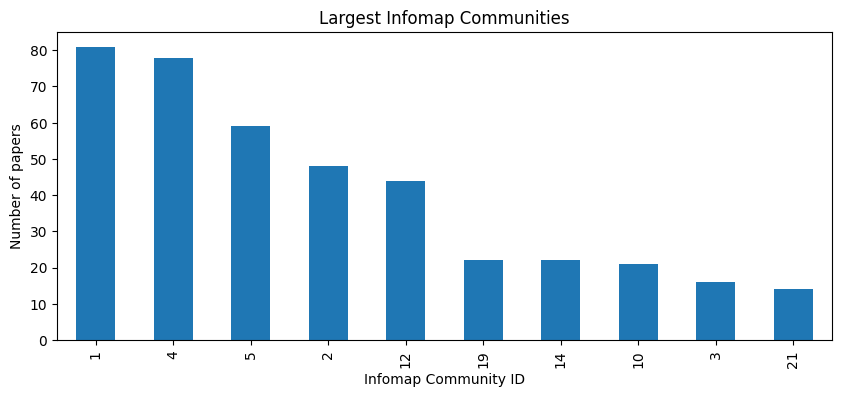

,infomap_community_id,num_papers,top_keywords,top_references,top_authors,composer_or_work_terms,representative_papers
0,1,81,"[(meter, 27), (rhythm, 25), (popular music, 8)...","[(lerdahl_and_jackendoff_1983, 38), (hasty_199...","[(Benadon, Fernando, 3), (Butterfield, Matthew...","[(Brahms, 4), (Herbie Hancock, 3), (Chameleon,...",[{'title_clean': 'Formal Functions of Metric D...
1,4,78,"[(form, 15), (sonata form, 12), (analysis, 9),...","[(caplin_1998, 48), (hepokoski_and_darcy_2006,...","[(Klorman, Edward, 4), (Rabinovitch, Gilad, 3)...","[(Haydn, 7), (Schubert, 7), (Schenker, 6), (Sc...",[{'title_clean': 'Perceiving Irony in Music: T...
2,5,59,"[(popular music, 23), (form, 12), (rock, 10), ...","[(stephenson_2002, 32), (biamonte_2010, 28), (...","[(Clercq, Trevor de, 4), (Spicer, Mark, 3), (T...","[(The Beatles, 3), (Radiohead, 3), (Schenkeria...",[{'title_clean': 'Teleology in Verse–Prechorus...
3,2,48,"[(transformational theory, 13), (animation, 6)...","[(lewin_1987, 30), (cohn_1996, 15), (cohn_1997...","[(Murphy, Scott, 3), (Roeder, John, 3), (Losad...","[(Tonnetz, 4), (Lewin, 3), (David Lewin, 3), (...",[{'title_clean': 'Exploring Tetrachordal Voice...
4,12,44,"[(performance, 11), (gesture, 9), (analysis, 7...","[(hatten_2004, 16), (mead_1999, 13), (zbikowsk...","[(Cox, Arnie, 2), (Montague, Eugene, 2), (Emme...","[(Schenker, 4), (Gubaidulina, 2), (Merleau-Pon...",[{'title_clean': 'Guitar Voicing in Pop-Rock M...
5,19,22,"[(Stravinsky, 7), (Kholopov, 6), (Russian musi...","[(taruskin_1996, 8), (carpenter_1995, 7), (tar...","[(Bazayev, Inessa, 4), (Ewell, Philip A., 2), ...","[(Stravinsky, 7), (Kholopov, 6), (Russian musi...",[{'title_clean': 'Modal Idioms and Their Rheto...
6,14,22,"[(improvisation, 11), (jazz, 10), (jazz analys...","[(berliner_1994, 15), (hodson_2007, 9), (monso...","[(Martin, Henry, 2), (Stover, Chris, 2), (Hann...","[(Steve Larson, 3), (Henry Martin, 2), (Charli...",[{'title_clean': 'Referents in the Palimpsests...
7,10,21,"[(semiotics, 8), (topic theory, 5), (topics, 4...","[(hatten_1994, 14), (agawu_1991, 12), (hatten_...","[(Neumeyer, David, 1), (McClary, Susan, 1), (J...","[(Mozart, 2), (Haydn, 2), (Rodelinda, 2), (Bee...",[{'title_clean': 'Humorous Script Oppositions ...
8,3,16,"[(Schoenberg, 7), (Arnold Schoenberg, 3), (chr...","[(forte_1973, 9), (schoenberg_1967, 5), (haimo...","[(Zeller, Matthew, 2), (Hussey, William, 1), (...","[(Schoenberg, 7), (Klangfarbenmelodie, 4), (Ar...",[{'title_clean': 'Harmonic “Quality” and Set-C...
9,21,14,"[(Ravel, 7), (timbre, 5), (orchestration, 3), ...","[(bregman_1990, 7), (nichols_2011, 6), (zank_2...","[(Beavers, Jennifer P., 2), (Leydon, Rebecca, ...","[(Ravel, 7), (Piano Concerto in G Major, 3), (...",[{'title_clean': 'Beyond Mere Novelty: Timbre ...


In [ ]:
papers_df['infomap_community_id'] = papers_df['id'].map(infomap_community_lookup)

infomap_community_sizes = (
    papers_df['infomap_community_id']
    .dropna()
    .astype(int)
    .value_counts()
    .sort_values(ascending=False)
    .rename_axis('infomap_community_id')
    .reset_index(name='num_papers')
)

print(f'Infomap communities detected: {len(infomap_communities)}')
print(f'Infomap codelength: {infomap_code_length:.6f}')
display(infomap_community_sizes.head(10))

infomap_community_sizes.head(10).plot(
    kind='bar',
    x='infomap_community_id',
    y='num_papers',
    figsize=(10, 4),
    legend=False
)
plt.title('Largest Infomap Communities')
plt.xlabel('Infomap Community ID')
plt.ylabel('Number of papers')
plt.show()


infomap_community_strength = dict(community_graph.degree(weight='weight'))
infomap_community_summaries = []

for infomap_community_id, community_papers in papers_df.dropna(subset=['infomap_community_id']).groupby('infomap_community_id'):
    community_papers = community_papers.copy()
    community_papers['infomap_community_strength'] = (
        community_papers['id'].map(infomap_community_strength).fillna(0)
    )

    representative_papers = (
        community_papers
        .sort_values(['infomap_community_strength', 'internal_in_degree'], ascending=False)
        [['title_clean', 'author_names', 'year']]
        .head(3)
        .to_dict('records')
    )

    top_refs = Counter(
        citations_df.loc[
            citations_df['paper_id'].isin(community_papers['id']),
            'citation_key'
        ]
    ).most_common(6)

    top_authors = Counter(
        author
        for authors in community_papers['author_list']
        for author in authors
    ).most_common(5)

    infomap_community_summaries.append({
        'infomap_community_id': int(infomap_community_id),
        'num_papers': len(community_papers),
        'top_keywords': flatten_counter(community_papers['keyword_list'], top_n=8),
        'top_references': top_refs,
        'top_authors': top_authors,
        'composer_or_work_terms': flatten_counter(
            community_papers['composer_or_work_terms'],
            top_n=6
        ),
        'representative_papers': representative_papers,
    })

infomap_community_summary_df = (
    pd.DataFrame(infomap_community_summaries)
    .sort_values('num_papers', ascending=False)
    .reset_index(drop=True)
)

display(infomap_community_summary_df.head(10))

,num_trials,codelength,num_communities,delta_codelength,improvement,best_so_far_codelength
0,1,7.208547,35,NaN,NaN,7.208547
1,2,7.206805,33,-1.741828e-03,1.741828e-03,7.206805
2,5,7.206805,33,2.664535e-14,-2.664535e-14,7.206805
3,10,7.202807,34,-3.998945e-03,3.998945e-03,7.202807
4,20,7.202135,35,-6.714489e-04,6.714489e-04,7.202135
5,30,7.201788,38,-3.472587e-04,3.472587e-04,7.201788
6,50,7.199239,36,-2.548842e-03,2.548842e-03,7.199239
7,100,7.197325,35,-1.914024e-03,1.914024e-03,7.197325
8,200,7.197325,35,0.000000e+00,-0.000000e+00,7.197325
9,500,7.196019,35,-1.305583e-03,1.305583e-03,7.196019


/tmp/ipykernel_4011/4117052142.py:110: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


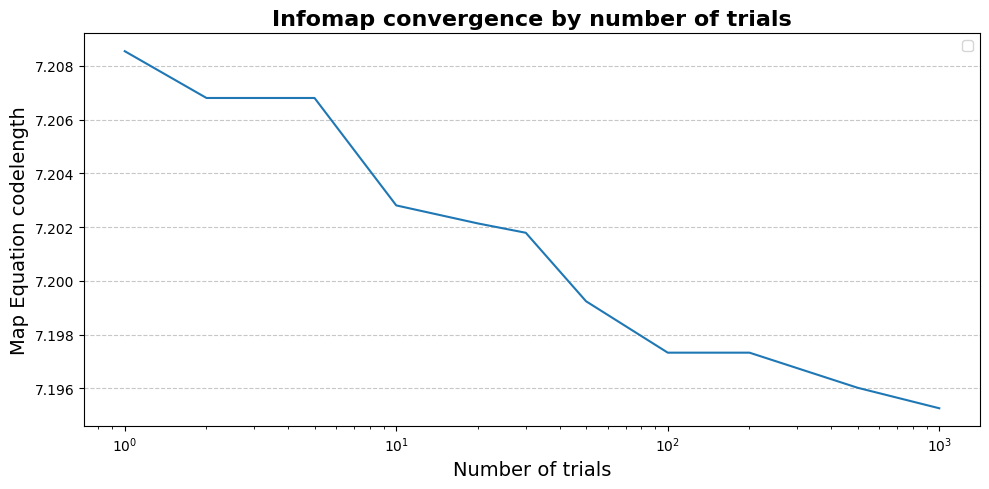

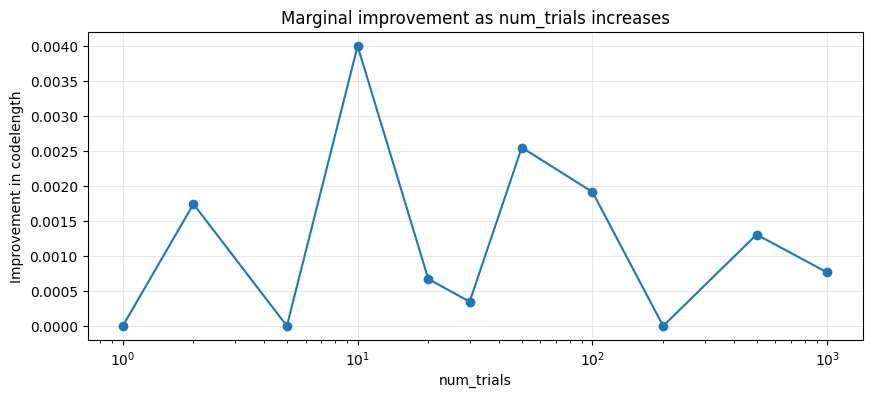

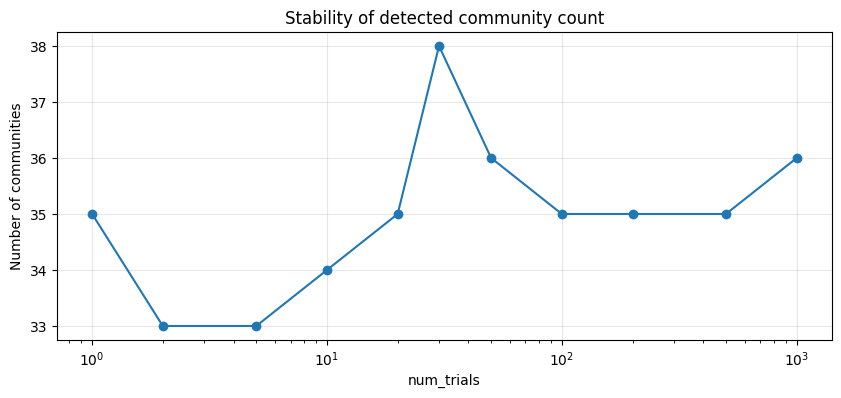

In [83]:
def run_infomap_once(
    G,
    weight='weight',
    seed=42,
    num_trials=1,
    silent=True,
    two_level=True
):
    if G.number_of_nodes() == 0:
        return {
            'partition': {},
            'communities': [],
            'codelength': np.nan,
            'num_communities': 0,
            'model': None,
            'id_to_label': {}
        }

    im = Infomap(
        silent=silent,
        seed=seed,
        num_trials=num_trials,
        two_level=two_level
    )

    id_to_label = im.add_networkx_graph(G, weight=weight)
    im.run()

    partition = {}
    for node in im.nodes:
        original_label = id_to_label[node.node_id]
        partition[original_label] = node.module_id

    unique_modules = sorted(set(partition.values()))
    module_relabel = {old: new for new, old in enumerate(unique_modules)}
    partition = {node: module_relabel[module] for node, module in partition.items()}

    communities_dict = {}
    for node, module in partition.items():
        communities_dict.setdefault(module, set()).add(node)
    communities = [communities_dict[k] for k in sorted(communities_dict)]

    return {
        'partition': partition,
        'communities': communities,
        'codelength': im.codelength,
        'num_communities': len(communities),
        'model': im,
        'id_to_label': id_to_label
    }


def infomap_convergence_by_trials(
    G,
    trial_grid=(1, 2, 5, 10, 20, 30, 50, 100, 200, 500, 1000),
    weight='weight',
    seed=42,
    silent=True,
    two_level=True
):
    records = []

    for nt in trial_grid:
        result = run_infomap_once(
            G,
            weight=weight,
            seed=seed,
            num_trials=nt,
            silent=silent,
            two_level=two_level
        )

        records.append({
            'num_trials': nt,
            'codelength': result['codelength'],
            'num_communities': result['num_communities']
        })

    conv_df = pd.DataFrame(records).sort_values('num_trials').reset_index(drop=True)

    conv_df['delta_codelength'] = conv_df['codelength'].diff()
    conv_df['improvement'] = -conv_df['delta_codelength']  # positive means better

    conv_df['best_so_far_codelength'] = conv_df['codelength'].cummin()

    return conv_df

infomap_conv_df = infomap_convergence_by_trials(
    community_graph,
    trial_grid=[1, 2, 5, 10, 20, 30, 50, 100, 200, 500, 1000],
    weight='weight',
    seed=42,
    silent=True,
    two_level=True
)

display(infomap_conv_df)

# raw codelength and best-so-far codelength
plt.figure(figsize=(10, 5))
plt.plot(
    infomap_conv_df['num_trials'],
    infomap_conv_df['codelength']
)
plt.xscale('log')
plt.xlabel('Number of trials', fontsize=14)
plt.ylabel('Map Equation codelength', fontsize=14)
plt.title('Infomap convergence by number of trials', fontsize=16, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

# improvement from one setting to the next
plt.figure(figsize=(10, 4))
plt.plot(
    infomap_conv_df['num_trials'],
    infomap_conv_df['improvement'].fillna(0),
    marker='o'
)
plt.xscale('log')
plt.xlabel('num_trials')
plt.ylabel('Improvement in codelength')
plt.title('Marginal improvement as num_trials increases')
plt.grid(alpha=0.3)
plt.show()

# number of communities detected
plt.figure(figsize=(10, 4))
plt.plot(
    infomap_conv_df['num_trials'],
    infomap_conv_df['num_communities'],
    marker='o'
)
plt.xscale('log')
plt.xlabel('num_trials')
plt.ylabel('Number of communities')
plt.title('Stability of detected community count')
plt.grid(alpha=0.3)
plt.show()

## 5.5 Gready Modularity

In [ ]:
import itertools
import networkx as nx
import matplotlib.pyplot as plt

Detected communities: 17
Modularity of weighted coupling partition: 0.497


,community_id,num_papers
0,0,122
1,1,98
2,2,94
3,3,80
4,4,62
5,5,31
6,6,30
7,7,12
8,8,8
9,9,4


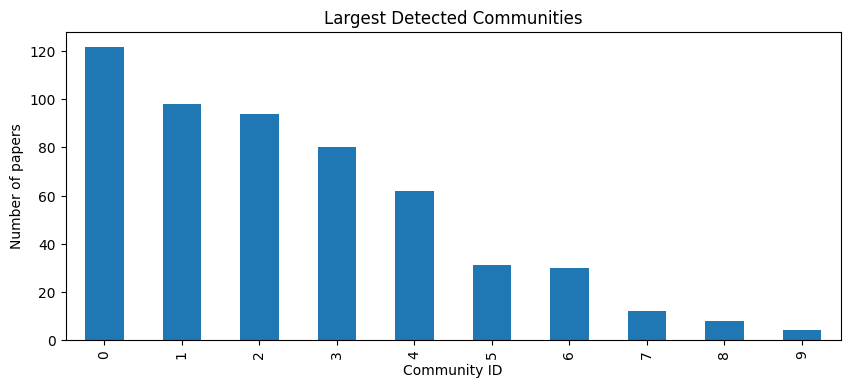

,community_id,num_papers,top_keywords,top_references,top_authors,composer_or_work_terms,representative_papers
0,0,122,"[(transformational theory, 16), (Schoenberg, 1...","[(lewin_1987, 41), (cohn_1996, 21), (forte_197...","[(Bazayev, Inessa, 4), (Murphy, Scott, 3), (Ro...","[(Schoenberg, 12), (Stravinsky, 7), (Kholopov,...",[{'title_clean': 'A Generalized Intervallic Ap...
1,1,98,"[(rhythm, 26), (meter, 25), (popular music, 12...","[(lerdahl_and_jackendoff_1983, 42), (hasty_199...","[(Benadon, Fernando, 3), (Butterfield, Matthew...","[(Brahms, 4), (Mozart, 4), (Herbie Hancock, 3)...",[{'title_clean': 'Formal Functions of Metric D...
2,2,94,"[(form, 15), (analysis, 11), (sonata form, 11)...","[(caplin_1998, 49), (hepokoski_and_darcy_2006,...","[(Klorman, Edward, 4), (Rabinovitch, Gilad, 4)...","[(Schenker, 9), (Haydn, 8), (Schubert, 8), (Be...",[{'title_clean': 'Perceiving Irony in Music: T...
3,3,80,"[(gesture, 9), (semiotics, 9), (timbre, 8), (a...","[(hatten_2004, 27), (hatten_1994, 16), (zbikow...","[(Cox, Arnie, 2), (Hatten, Robert S., 2), (Mon...","[(Ravel, 7), (Gubaidulina, 4), (Schumann, 3), ...",[{'title_clean': 'What is Musical Meaning? The...
4,4,62,"[(popular music, 23), (form, 10), (harmony, 9)...","[(stephenson_2002, 28), (biamonte_2010, 28), (...","[(Temperley, David, 4), (Spicer, Mark, 3), (Cl...","[(Schenkerian analysis, 3), (The Beatles, 3), ...",[{'title_clean': 'Teleology in Verse–Prechorus...
5,5,31,"[(improvisation, 18), (jazz, 10), (analysis, 4...","[(berliner_1994, 15), (monson_1996, 11), (hods...","[(Martin, Henry, 2), (Steinbeck, Paul, 2), (St...","[(Steve Larson, 3), (Henry Martin, 2), (Charli...",[{'title_clean': 'Referents in the Palimpsests...
6,6,30,"[(hip-hop, 6), (rap, 4), (rhythm, 4), (pedagog...","[(krims_2000, 13), (adams_2008, 9), (adams_200...","[(Adams, Kyle, 3), (Boone, Christine, 2), (Kom...","[(Kendrick Lamar, 4), (Meow the Jewels, 2), (R...",[{'title_clean': 'The Many Paths of Decoloniza...
7,7,12,"[(counterpoint, 6), (Renaissance, 5), (analysi...","[(schubert_2007, 8), (canguilhem_2011, 4), (mi...","[(Cumming, Julie E., 2), (Schubert, Peter, 2),...","[(Renaissance, 5), (Counterpoint, 3), (J. S. B...",[{'title_clean': 'Species Counterpoint with a ...
8,8,8,"[(tonality, 2), (temperament, 1), (tuning, 1),...","[(carey_and_clampitt_1989, 4), (meeùs_2000, 4)...","[(Guillotel-Nothmann, Christophe, 2), (Amiot, ...","[(Fourier transform, 1), (Lehman, 1), (J.S. Ba...",[{'title_clean': 'Fundamental Bass and Real Ba...
9,9,4,"[(Conlon Nancarrow, 2), (tempo canons, 1), (ir...","[(gann_1995, 4), (hocker_2012, 4), (callender_...","[(Callender, Clifton, 1), (Murcott, Dominic, 1...","[(Conlon Nancarrow, 2), (Impossible Brilliance...","[{'title_clean': 'Conlon Nancarrow, “Hot” Jazz..."


In [ ]:
def flatten_counter(series, top_n=10):
    values = []
    for item in series:
        if isinstance(item, list):
            values.extend(item)
    return Counter(values).most_common(top_n)


def extract_italicized_works(text):
    if not isinstance(text, str):
        return []
    return [clean_text(match) for match in re.findall(r'<i>(.*?)</i>', text)]


def extract_composer_or_work_terms(row):
    candidates = []
    if isinstance(row.get('keyword_list'), list):
        candidates.extend([kw for kw in row['keyword_list'] if isinstance(kw, str) and kw[:1].isupper()])
    for field in (row.get('title', ''), row.get('abstract', '')):
        candidates.extend(extract_italicized_works(field))
    return [term for term in candidates if term]


papers_df['composer_or_work_terms'] = papers_df.apply(extract_composer_or_work_terms, axis=1)
community_graph = bibliographic_coupling_graph.subgraph(
    [node for node, degree in bibliographic_coupling_graph.degree() if degree > 0]
).copy()

communities = list(nx.community.greedy_modularity_communities(community_graph, weight='weight'))
community_lookup = {
    node: community_id
    for community_id, community in enumerate(communities)
    for node in community
}

papers_df['community_id'] = papers_df['id'].map(community_lookup)
community_modularity = nx.community.modularity(community_graph, communities, weight='weight')
community_sizes = (
    papers_df['community_id']
    .dropna()
    .astype(int)
    .value_counts()
    .sort_values(ascending=False)
    .rename_axis('community_id')
    .reset_index(name='num_papers')
)

print(f'Detected communities: {len(communities)}')
print(f'Modularity of weighted coupling partition: {community_modularity:.3f}')
display(community_sizes.head(10))

community_sizes.head(10).plot(kind='bar', x='community_id', y='num_papers', figsize=(10, 4), legend=False)
plt.title('Largest Detected Communities')
plt.xlabel('Community ID')
plt.ylabel('Number of papers')
plt.show()

community_strength = dict(community_graph.degree(weight='weight'))
community_summaries = []
for community_id, community_papers in papers_df.dropna(subset=['community_id']).groupby('community_id'):
    community_papers = community_papers.copy()
    community_papers['community_strength'] = community_papers['id'].map(community_strength).fillna(0)
    representative_papers = (
        community_papers
        .sort_values(['community_strength', 'internal_in_degree'], ascending=False)
        [['title_clean', 'author_names', 'year']]
        .head(3)
        .to_dict('records')
    )

    top_refs = Counter(
        citations_df.loc[citations_df['paper_id'].isin(community_papers['id']), 'citation_key']
    ).most_common(6)
    top_authors = Counter(
        author
        for authors in community_papers['author_list']
        for author in authors
    ).most_common(5)

    community_summaries.append({
        'community_id': int(community_id),
        'num_papers': len(community_papers),
        'top_keywords': flatten_counter(community_papers['keyword_list'], top_n=8),
        'top_references': top_refs,
        'top_authors': top_authors,
        'composer_or_work_terms': flatten_counter(community_papers['composer_or_work_terms'], top_n=6),
        'representative_papers': representative_papers,
    })

community_summary_df = pd.DataFrame(community_summaries).sort_values('num_papers', ascending=False)
display(community_summary_df.head(10))


,num_communities,target_k,modularity,best_so_far
19,21,21,0.496181,0.496529
18,20,20,0.496287,0.496529
17,19,19,0.496389,0.496529
16,18,18,0.496492,0.496529
15,17,17,0.496529,0.496529
14,16,16,0.496437,0.496437
13,15,15,0.496341,0.496341
12,14,14,0.494389,0.494389
11,13,13,0.486071,0.486071
10,12,12,0.456817,0.456817


/tmp/ipykernel_4011/1872607500.py:55: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


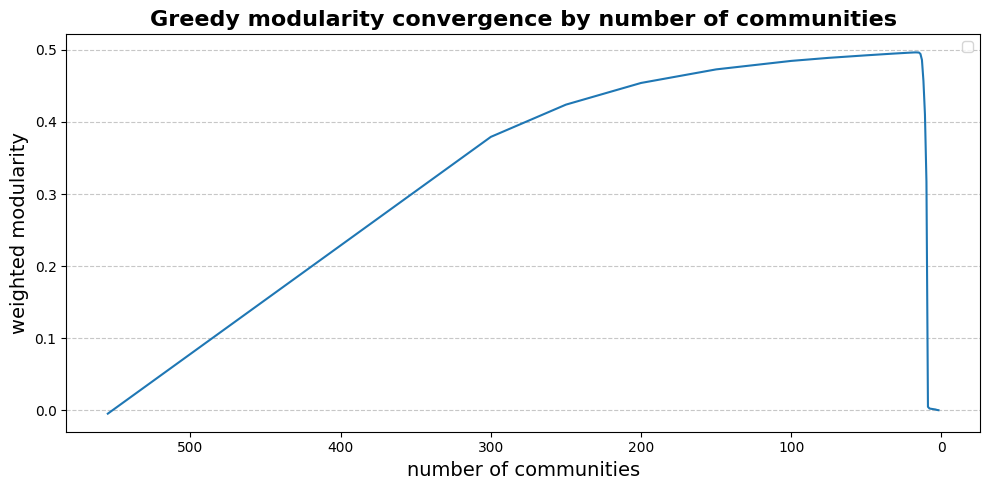

In [84]:
G = community_graph.copy()

n_nodes = G.number_of_nodes()

candidate_k = sorted(set(
    list(range(2, min(50, n_nodes) + 1)) +
    [75, 100, 150, 200, 250, 300, n_nodes]
))

candidate_k = [k for k in candidate_k if 2 <= k <= n_nodes]

modularity_records = []

for k in candidate_k:
    # Stop the greedy merging once k communities remain
    comms_k = list(
        nx.community.greedy_modularity_communities(
            G,
            weight='weight',
            cutoff=k,
            best_n=k
        )
    )

    Q_k = nx.community.modularity(G, comms_k, weight='weight')

    modularity_records.append({
        'num_communities': len(comms_k),
        'target_k': k,
        'modularity': Q_k
    })

modularity_df = (
    pd.DataFrame(modularity_records)
    .drop_duplicates(subset='num_communities')
    .sort_values('num_communities', ascending=False)
)

modularity_df = modularity_df.sort_values('num_communities', ascending=False)
modularity_df['best_so_far'] = modularity_df['modularity'][::-1].cummax()[::-1]

display(modularity_df.tail(20))

plt.figure(figsize=(10, 5))

plt.plot(
    modularity_df['num_communities'],
    modularity_df['modularity']
)

plt.gca().invert_xaxis()
plt.xlabel('number of communities', fontsize=14)
plt.ylabel('weighted modularity', fontsize=14)
plt.title('Greedy modularity convergence by number of communities', fontsize=16, fontweight='bold')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# **6. Objective 3: Measure Thematic Coherence of Communities**

We compare the thematic coherence of the four retained community-detection methods by asking whether papers placed in the same detected group are more similar than papers placed in different groups.


### 6.1 Coherence Helper Functions


In [ ]:
def mean_pairwise_jaccard(list_of_sets, labels):
    within_scores = []
    across_scores = []
    for i in range(len(list_of_sets)):
        for j in range(i + 1, len(list_of_sets)):
            union = list_of_sets[i] | list_of_sets[j]
            score = len(list_of_sets[i] & list_of_sets[j]) / len(union) if union else 0.0
            if labels[i] == labels[j]:
                within_scores.append(score)
            else:
                across_scores.append(score)
    return float(np.mean(within_scores)), float(np.mean(across_scores))


def mean_pairwise_from_matrix(similarity_matrix, labels):
    within_scores = []
    across_scores = []
    n = similarity_matrix.shape[0]
    for i in range(n):
        for j in range(i + 1, n):
            if labels[i] == labels[j]:
                within_scores.append(float(similarity_matrix[i, j]))
            else:
                across_scores.append(float(similarity_matrix[i, j]))
    return float(np.mean(within_scores)), float(np.mean(across_scores))


def coherence_for_partition(dataframe, partition_column, partition_name):
    analysis_df = dataframe.dropna(subset=[partition_column]).reset_index(drop=True).copy()
    if analysis_df.empty or analysis_df[partition_column].nunique() < 2:
        return pd.DataFrame()

    partition_labels = analysis_df[partition_column].astype(int).to_numpy()
    keyword_sets = analysis_df['keyword_list'].apply(lambda x: set(x) if isinstance(x, list) else set()).tolist()
    author_sets = analysis_df['author_list'].apply(lambda x: set(x) if isinstance(x, list) else set()).tolist()
    composer_sets = analysis_df['composer_or_work_terms'].apply(lambda x: set(x) if isinstance(x, list) else set()).tolist()

    keyword_within, keyword_across = mean_pairwise_jaccard(keyword_sets, partition_labels)
    author_within, author_across = mean_pairwise_jaccard(author_sets, partition_labels)
    composer_within, composer_across = mean_pairwise_jaccard(composer_sets, partition_labels)

    title_vectorizer = TfidfVectorizer(stop_words='english')
    title_matrix = title_vectorizer.fit_transform(analysis_df['title_clean'].fillna(''))
    title_cosine = cosine_similarity(title_matrix)
    title_within, title_across = mean_pairwise_from_matrix(title_cosine, partition_labels)

    citation_mlb = MultiLabelBinarizer(sparse_output=True)
    citation_profile = citation_mlb.fit_transform(
        analysis_df['citation_keys'].apply(lambda x: x if isinstance(x, list) else [])
    )
    citation_cosine = cosine_similarity(citation_profile)
    citation_within, citation_across = mean_pairwise_from_matrix(citation_cosine, partition_labels)

    return pd.DataFrame([
        {'partition': partition_name, 'metric': 'Keyword overlap (Jaccard)', 'within_group_mean': keyword_within, 'across_group_mean': keyword_across, 'difference': keyword_within - keyword_across},
        {'partition': partition_name, 'metric': 'Title cosine similarity', 'within_group_mean': title_within, 'across_group_mean': title_across, 'difference': title_within - title_across},
        {'partition': partition_name, 'metric': 'Cited-reference cosine similarity', 'within_group_mean': citation_within, 'across_group_mean': citation_across, 'difference': citation_within - citation_across},
        {'partition': partition_name, 'metric': 'Author overlap (Jaccard)', 'within_group_mean': author_within, 'across_group_mean': author_across, 'difference': author_within - author_across},
        {'partition': partition_name, 'metric': 'Composer/work overlap (Jaccard)', 'within_group_mean': composer_within, 'across_group_mean': composer_across, 'difference': composer_within - composer_across},
    ])


### 6.2 Compare Coherence Across the Four Retained Methods


In [ ]:
coherence_frames = []
for partition_column, partition_name in [
    ('sbm_block_id', 'SBM blocks'),
    ('spectral_community_id', 'Spectral embedding groups'),
]:
    coherence_frames.append(coherence_for_partition(papers_df, partition_column, partition_name))

coherence_df = pd.concat([frame for frame in coherence_frames if not frame.empty], ignore_index=True)
display(coherence_df.sort_values(['metric', 'partition']))

coherence_pivot = coherence_df.pivot(index='metric', columns='partition', values='difference')
display(coherence_pivot.round(3))


,partition,metric,within_group_mean,across_group_mean,difference
3,SBM blocks,Author overlap (Jaccard),0.001758,0.001753,0.000005
8,Spectral embedding groups,Author overlap (Jaccard),0.001813,0.000762,0.001051
2,SBM blocks,Cited-reference cosine similarity,0.014214,0.013019,0.001194
7,Spectral embedding groups,Cited-reference cosine similarity,0.013895,0.003745,0.010151
4,SBM blocks,Composer/work overlap (Jaccard),0.001618,0.001354,0.000264
9,Spectral embedding groups,Composer/work overlap (Jaccard),0.002051,0.000752,0.001299
0,SBM blocks,Keyword overlap (Jaccard),0.005956,0.005146,0.000810
5,Spectral embedding groups,Keyword overlap (Jaccard),0.007004,0.002281,0.004723
1,SBM blocks,Title cosine similarity,0.008711,0.008152,0.000558
6,Spectral embedding groups,Title cosine similarity,0.009368,0.006944,0.002423


partition,SBM blocks,Spectral embedding groups
metric,,
Author overlap (Jaccard),0.000,0.001
Cited-reference cosine similarity,0.001,0.010
Composer/work overlap (Jaccard),0.000,0.001
Keyword overlap (Jaccard),0.001,0.005
Title cosine similarity,0.001,0.002


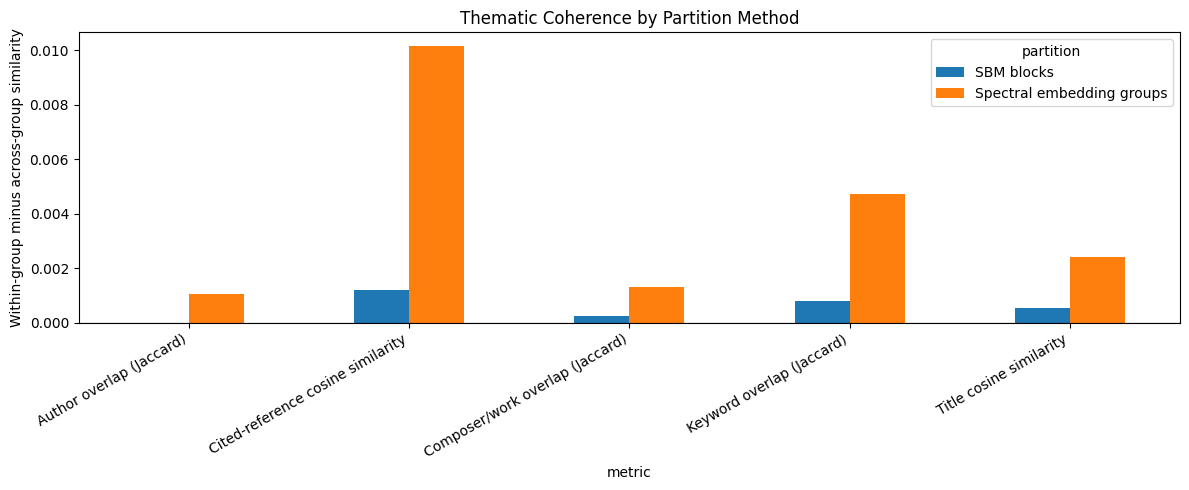

In [ ]:
coherence_pivot.plot(kind='bar', figsize=(12, 5))
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=30, ha='right')
plt.ylabel('Within-group minus across-group similarity')
plt.title('Thematic Coherence by Partition Method')
plt.tight_layout()
plt.show()


## **7. Objective 4: Compare Community Detection Methods**

### 7.1 Comparison of SBM and Spectral Communities

Adjusted Rand Index (ARI) between SBM and Spectral communities: -0.015
Normalized Mutual Information (NMI) between SBM and Spectral communities: 0.064


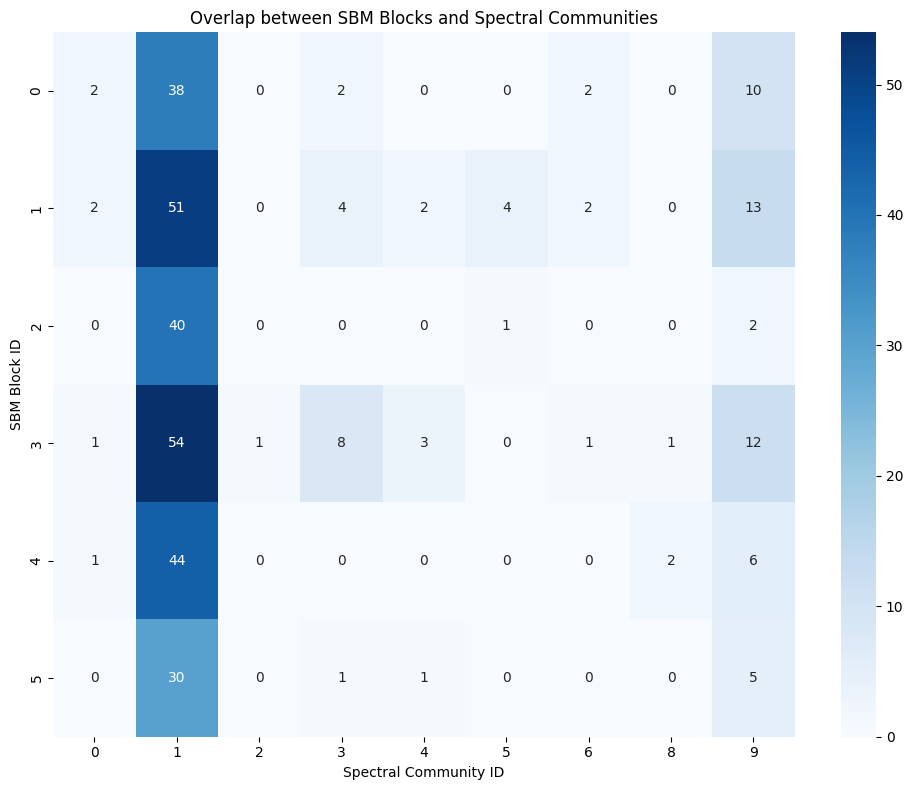

In [ ]:
merged_communities = papers_df.dropna(subset=['sbm_block_id', 'spectral_community_id']).copy()

if not merged_communities.empty:
    sbm_labels_comp = merged_communities['sbm_block_id'].astype(int)
    spectral_labels_comp = merged_communities['spectral_community_id'].astype(int)

    ari = adjusted_rand_score(sbm_labels_comp, spectral_labels_comp)
    nmi = normalized_mutual_info_score(sbm_labels_comp, spectral_labels_comp)

    print(f'Adjusted Rand Index (ARI) between SBM and Spectral communities: {ari:.3f}')
    print(f'Normalized Mutual Information (NMI) between SBM and Spectral communities: {nmi:.3f}')

    # Create a cross-tabulation (contingency table)
    contingency_table = pd.crosstab(sbm_labels_comp, spectral_labels_comp)

    plt.figure(figsize=(10, 8))
    sns.heatmap(contingency_table, annot=True, fmt='d', cmap='Blues')
    plt.title('Overlap between SBM Blocks and Spectral Communities')
    plt.xlabel('Spectral Community ID')
    plt.ylabel('SBM Block ID')
    plt.tight_layout()
    plt.show()
else:
    print("No overlapping papers between SBM and Spectral communities for comparison.")

### Keyword Similarity Between SBM and Spectral Communities

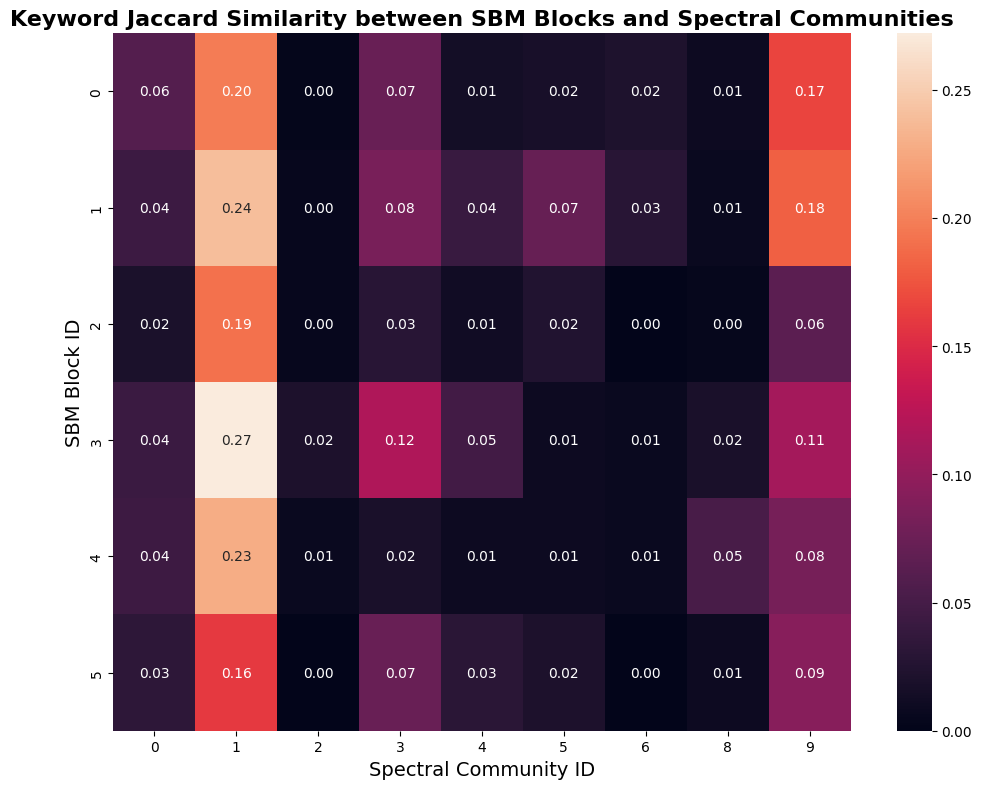

In [ ]:
# Get unique SBM and Spectral labels from merged_communities
sbm_labels_comp = merged_communities['sbm_block_id'].astype(int).unique()
spectral_labels_comp = merged_communities['spectral_community_id'].astype(int).unique()

# Create aggregated keyword sets for each SBM block
sbm_keyword_sets = {}
for sbm_id in sbm_labels_comp:
    block_papers = merged_communities[merged_communities['sbm_block_id'] == sbm_id]
    all_keywords = set()
    for keywords_list in block_papers['keyword_list']:
        if isinstance(keywords_list, list):
            all_keywords.update(keywords_list)
    sbm_keyword_sets[sbm_id] = all_keywords

# Create aggregated keyword sets for each Spectral community
spectral_keyword_sets = {}
for spectral_id in spectral_labels_comp:
    community_papers = merged_communities[merged_communities['spectral_community_id'] == spectral_id]
    all_keywords = set()
    for keywords_list in community_papers['keyword_list']:
        if isinstance(keywords_list, list):
            all_keywords.update(keywords_list)
    spectral_keyword_sets[spectral_id] = all_keywords

# Initialize a matrix to store Jaccard similarities
jaccard_similarity_matrix = pd.DataFrame(
    np.zeros((len(sbm_labels_comp), len(spectral_labels_comp))),
    index=sorted(sbm_labels_comp),
    columns=sorted(spectral_labels_comp)
)

# Calculate Jaccard similarity for each pair
for sbm_id in sorted(sbm_labels_comp):
    for spectral_id in sorted(spectral_labels_comp):
        set1 = sbm_keyword_sets[sbm_id]
        set2 = spectral_keyword_sets[spectral_id]
        intersection = len(set1.intersection(set2))
        union = len(set1.union(set2))
        jaccard = intersection / union if union > 0 else 0
        jaccard_similarity_matrix.loc[sbm_id, spectral_id] = jaccard

# Display the matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(jaccard_similarity_matrix, annot=True, fmt=".2f")
plt.title('Keyword Jaccard Similarity between SBM Blocks and Spectral Communities', fontsize=16, fontweight='bold')
plt.xlabel('Spectral Community ID', fontsize=14)
plt.ylabel('SBM Block ID', fontsize=14)
plt.tight_layout()
plt.show()

### 7.2 Summaries of Individual Communities

#### SBM Block Summaries

In [ ]:
display(sbm_block_summary_df)

,sbm_block_id,num_papers,top_keywords,top_references,top_authors,composer_or_work_terms,representative_papers
0,3,81,"[(popular music, 6), (rhythm, 5), (analysis, 4...","[(rothstein_1989, 12), (lerdahl_and_jackendoff...","[(Ewell, Philip A., 3), (Tymoczko, Dmitri, 2),...","[(J. S. Bach, 4), (Ravel, 3), (Russian music, ...",[{'title_clean': 'Recapitulatory Compressions ...
1,1,78,"[(analysis, 7), (form, 5), (improvisation, 5),...","[(caplin_1998, 12), (gjerdingen_2007, 8), (hep...","[(Benadon, Fernando, 2), (Murphy, Scott, 2), (...","[(Schenker, 4), (Ravel, 3), (Bartók, 2), (Guba...",[{'title_clean': 'On Duration and Developing V...
2,0,54,"[(rhythm, 6), (performance, 4), (improvisation...","[(hasty_1997, 9), (hatten_1994, 7), (caplin_19...","[(Stover, Chris, 2), (Zeller, Matthew, 2), (Ca...","[(Schoenberg, 4), (Klangfarbenmelodie, 4), (Ch...",[{'title_clean': 'Melodic Organization and Seq...
3,4,53,"[(form, 10), (rhythm, 6), (meter, 6), (improvi...","[(caplin_1998, 18), (hepokoski_and_darcy_2006,...","[(Hatten, Robert S., 2), (Benadon, Fernando, 1...","[(Schenker, 2), (Mozart, 2), (Chromaticism, 2)...",[{'title_clean': 'Brahmsian Articulation: Ambi...
4,2,43,"[(popular music, 15), (form, 10), (harmony, 7)...","[(stephenson_2002, 20), (caplin_1998, 18), (le...","[(Clercq, Trevor de, 3), (Duinker, Ben, 3), (T...","[(Schenkerian analysis, 3), (Mozart, 2), (Lewi...",[{'title_clean': 'Formal Functions of Metric D...
5,5,37,"[(popular music, 5), (transformational theory,...","[(caplin_1998, 9), (hepokoski_and_darcy_2006, ...","[(Polak, Rainer, 2), (Butterfield, Matthew W.,...","[(Formenlehre, 3), (Lewin, 2), (Klumpenhouwer ...",[{'title_clean': 'Extending the Parallel Multi...


#### Spectral Community Summaries

In [ ]:
display(spectral_community_summary_df)

,spectral_community_id,num_papers,top_keywords,top_references,top_authors,composer_or_work_terms,representative_papers
0,1,365,"[(popular music, 41), (form, 39), (analysis, 3...","[(caplin_1998, 79), (lerdahl_and_jackendoff_19...","[(Temperley, David, 5), (Rabinovitch, Gilad, 5...","[(Schenker, 17), (Mozart, 12), (Haydn, 10), (S...",[{'title_clean': 'Formal Functions of Metric D...
1,9,63,"[(transformational theory, 12), (Schoenberg, 8...","[(lewin_1987, 29), (cohn_1996, 15), (cohn_1997...","[(Murphy, Scott, 3), (Roeder, John, 3), (Losad...","[(Schoenberg, 8), (Elliott Carter, 4), (Klangf...",[{'title_clean': 'Exploring Tetrachordal Voice...
2,3,23,"[(Stravinsky, 7), (Kholopov, 6), (Russian musi...","[(taruskin_1996, 8), (carpenter_1995, 7), (tar...","[(Bazayev, Inessa, 4), (Ewell, Philip A., 2), ...","[(Stravinsky, 7), (Kholopov, 6), (Russian musi...",[{'title_clean': 'Harmonic “Quality” and Set-C...
3,0,21,"[(Gubaidulina, 3), (perception, 2), (performan...","[(_, 6), (sterne_2003, 5), (sterne_2012, 4), (...","[(Green, Burdette, 1), (Berry, Michael, 1), (B...","[(Gubaidulina, 3), (Claude Vivier, 2), (Boucha...",[{'title_clean': 'Music’s Stubborn Enchantment...
4,2,17,"[(J. S. Bach, 3), (Performance, 2), (Conlon Na...","[(butt_2002, 2), (leech-wilkinson_2009a, 2), (...","[(Leech-Wilkinson, Daniel, 1), (Johnston, Blai...","[(J. S. Bach, 3), (Pansori, 3), (Performance, ...",[{'title_clean': 'Prelude on a Partimento: Inv...
5,5,17,"[(tonality, 3), (centricity, 2), (pitch-class ...","[(forte_1973, 6), (clough_and_douthett_1991, 5...","[(Guillotel-Nothmann, Christophe, 2), (Samplas...","[(Quiet City, 2), (IcVSIM, 1), (ISIM2, 1), (AN...",[{'title_clean': 'Feedback and Feedforward Mod...
6,4,15,"[(improvisation, 5), (analysis, 3), (counterpo...","[(benson_2003, 5), (owens_1997, 4), (wegman_19...","[(Cumming, Julie E., 2), (Traut, Don, 1), (Ley...","[(Schenker, 1), (Counterpoint: A Species Appro...",[{'title_clean': 'Improvisation as a Way of Kn...
7,8,11,"[(chromaticism, 2), (Schoenberg, 2), (Conlon N...","[(gann_1995, 4), (hocker_2012, 4), (babbitt_19...","[(Hussey, William, 1), (Guerrero, Jeannie Ma.,...","[(Schoenberg, 2), (A Survivor from Warsaw, 2),...",[{'title_clean': 'Extraordinary Function and t...
8,6,10,"[(pedagogy, 3), (public music theory, 2), (dec...","[(ewell_2020, 4), (hisama_2021, 4), (lett_2023...","[(Lumsden, Rachel, 2), (Attas, Robin, 2), (Boy...","[(Indigenization, 2), (The Girl’s Own Paper, 1...",[{'title_clean': 'The Many Paths of Decoloniza...
9,7,7,"[(post-structuralism, 4), (Bloom, 3), (Straus,...","[(straus_1990, 5), (korsyn_1991, 4), (klein_20...","[(Marion, Gregory J., 1), (Rusch, René, 1), (V...","[(Bloom, 3), (Straus, 2), (Krims, 2), (Debussy...",[{'title_clean': 'Debussy and Recollection: tr...


### 7.3 Community Size Visualizations with Top Keywords

#### SBM Community Sizes by Top Keywords

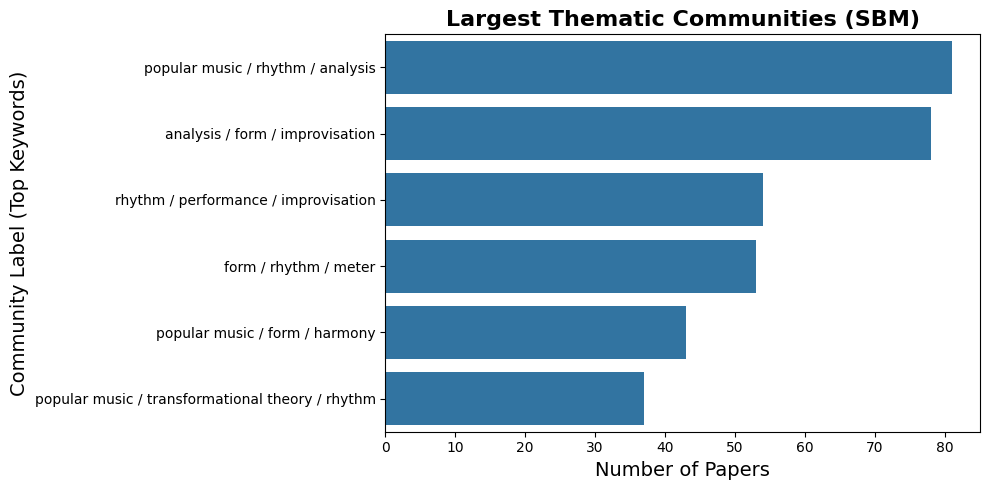

In [ ]:
# Prepare SBM data for plotting
sbm_plot_df = sbm_block_summary_df.copy()
sbm_plot_df['community_label'] = sbm_plot_df['top_keywords'].apply(lambda x: ' / '.join([kw[0] for kw in x[:3]]))

plt.figure(figsize=(10, 5), dpi=100)
sns.barplot(x='num_papers', y='community_label', data=sbm_plot_df.sort_values('num_papers', ascending=False))
plt.title('Largest Thematic Communities (SBM)', fontsize=16, fontweight='bold')
plt.xlabel('Number of Papers', fontsize=14)
plt.ylabel('Community Label (Top Keywords)', fontsize=14)
plt.tight_layout()
plt.show()

#### Spectral Community Sizes by Top Keywords

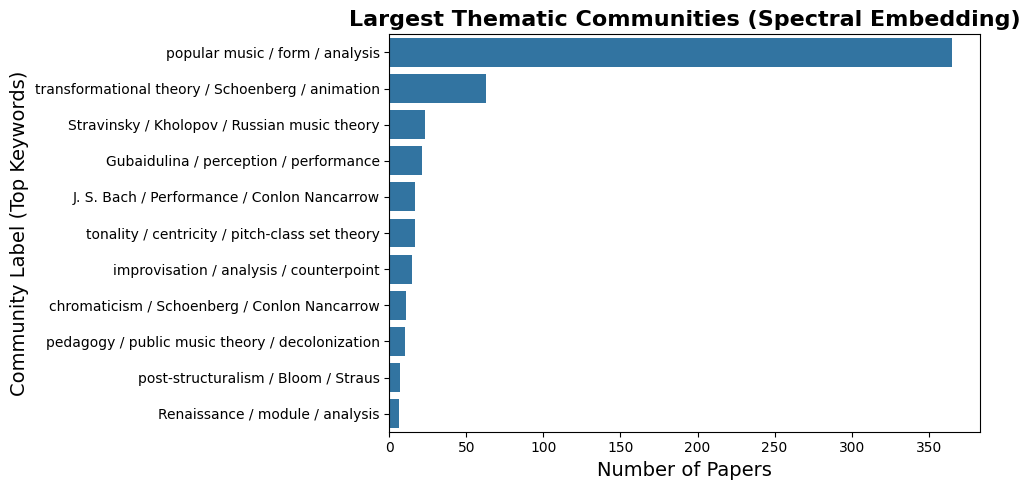

In [ ]:
# Prepare Spectral data for plotting
spectral_plot_df = spectral_community_summary_df.copy()
spectral_plot_df['community_label'] = spectral_plot_df['top_keywords'].apply(lambda x: ' / '.join([kw[0] for kw in x[:3]]))

plt.figure(figsize=(10, 5), dpi=100)
sns.barplot(x='num_papers', y='community_label', data=spectral_plot_df.sort_values('num_papers', ascending=False))
plt.title('Largest Thematic Communities (Spectral Embedding)', fontsize=16, fontweight='bold')
plt.xlabel('Number of Papers', fontsize=14)
plt.ylabel('Community Label (Top Keywords)', fontsize=14)
plt.tight_layout()
plt.show()

#### InfoMap by Top Key Words

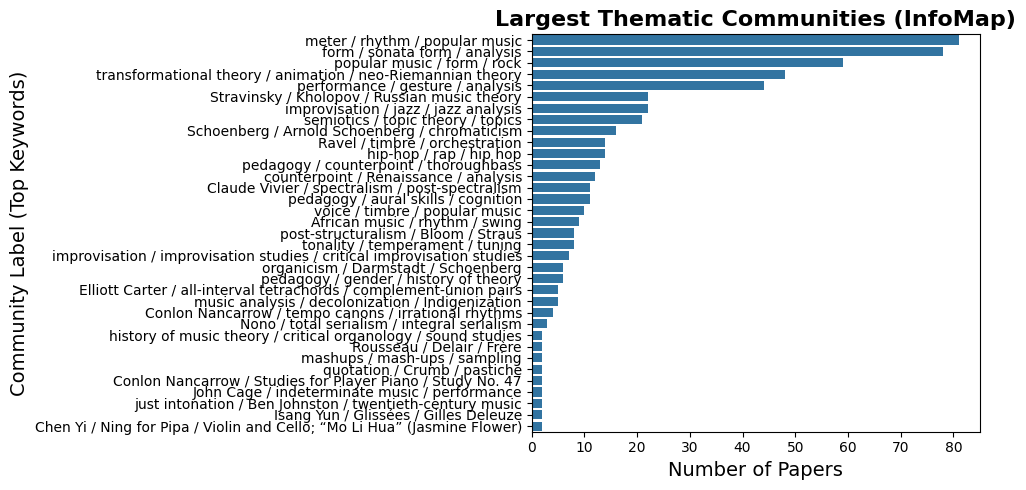

In [ ]:
infomap_plot_df = infomap_community_summary_df.copy()

infomap_plot_df['community_label'] = infomap_plot_df['top_keywords'].apply(
    lambda x: ' / '.join([kw[0] for kw in x[:3]])
    if isinstance(x, list) and len(x) > 0
    else 'No keywords'
)

plt.figure(figsize=(10, 5), dpi=100)
sns.barplot(
    x='num_papers',
    y='community_label',
    data=infomap_plot_df.sort_values('num_papers', ascending=False)
)

plt.title('Largest Thematic Communities (InfoMap)', fontsize=16, fontweight='bold')
plt.xlabel('Number of Papers', fontsize=14)
plt.ylabel('Community Label (Top Keywords)', fontsize=14)
plt.tight_layout()
plt.show()

#### Greedy Modularity by Top Key Words

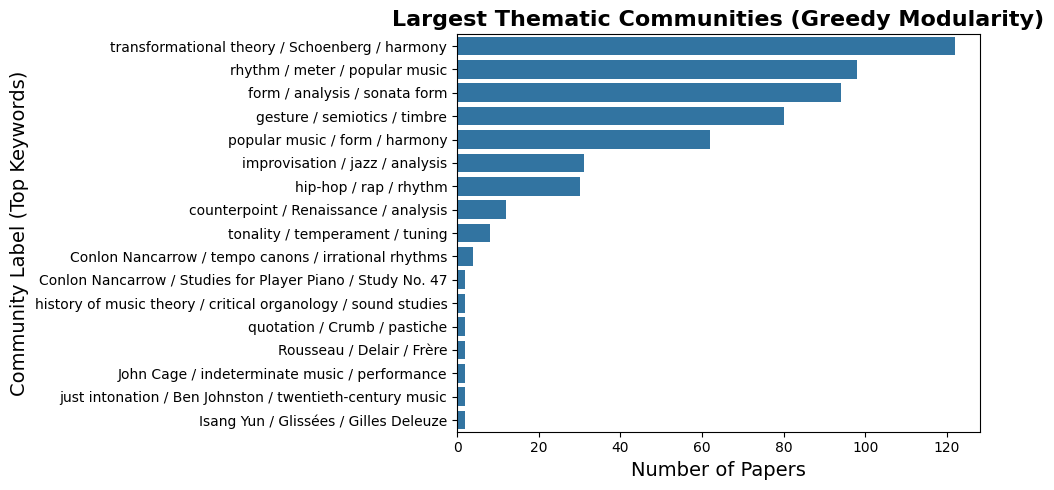

In [ ]:
greedy_plot_df = community_summary_df.copy()

greedy_plot_df['community_label'] = greedy_plot_df['top_keywords'].apply(
    lambda x: ' / '.join([kw[0] for kw in x[:3]]) if isinstance(x, list) and len(x) > 0 else 'No keywords'
)

plt.figure(figsize=(10, 5), dpi=100)
sns.barplot(
    x='num_papers',
    y='community_label',
    data=greedy_plot_df.sort_values('num_papers', ascending=False)
)
plt.title('Largest Thematic Communities (Greedy Modularity)', fontsize=16, fontweight='bold')
plt.xlabel('Number of Papers', fontsize=14)
plt.ylabel('Community Label (Top Keywords)', fontsize=14)
plt.tight_layout()
plt.show()

## 7.4 Community Graph(Colored)

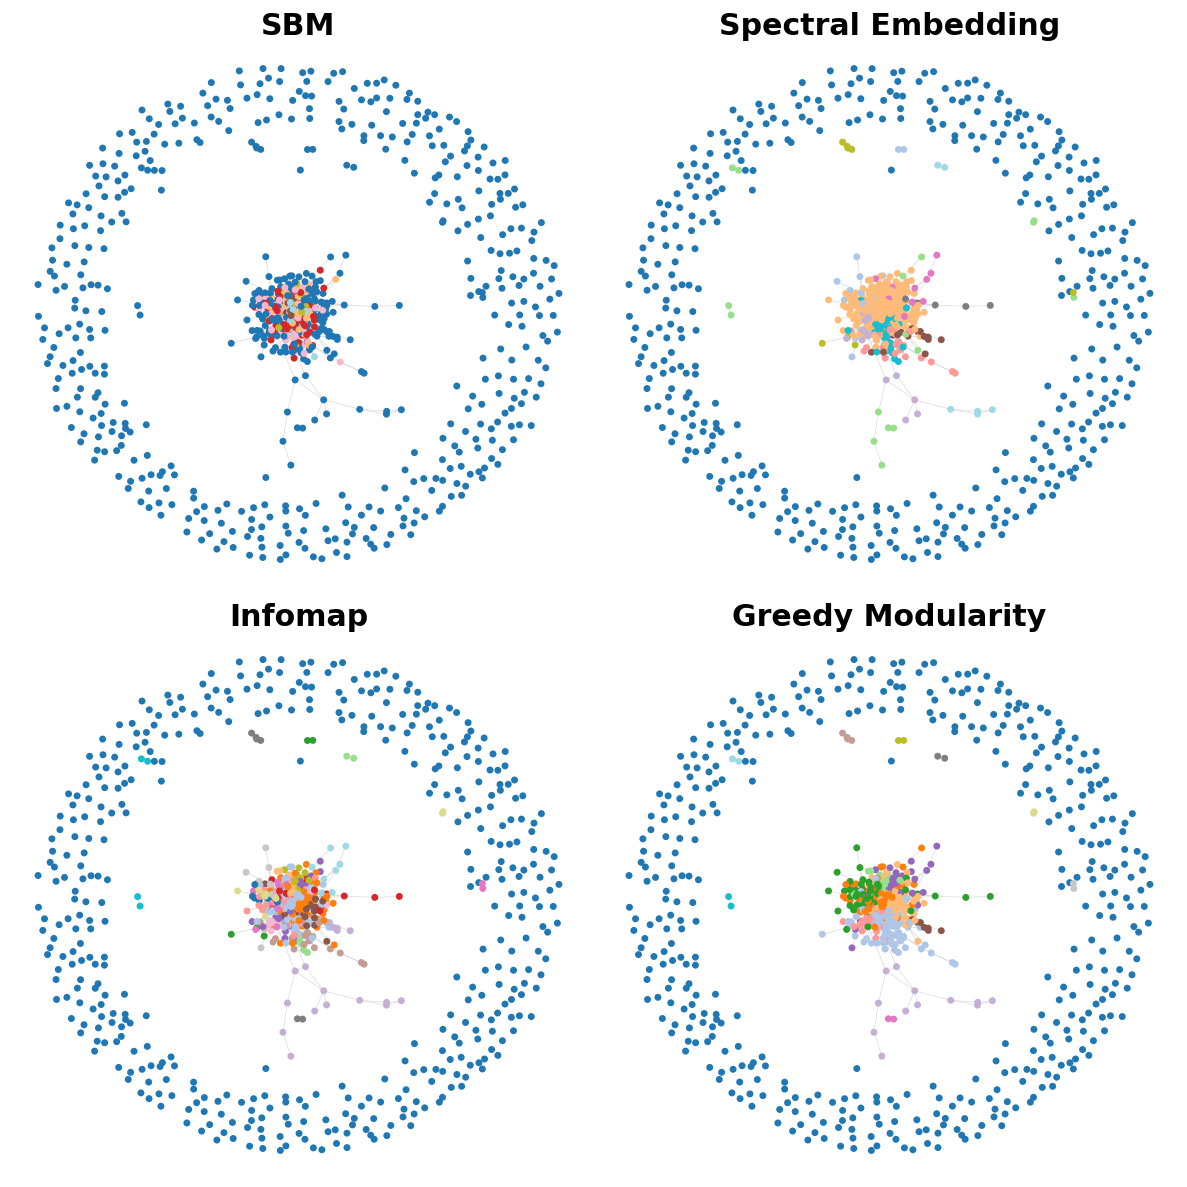

In [ ]:
isolated_nodes = set(nx.isolates(bibliographic_coupling_graph))

method_partitions = {
    "SBM": sbm_partition,
    "Spectral Embedding": spectral_community_lookup,
    "Infomap": infomap_community_lookup,
    "Greedy Modularity": community_lookup,
}

pos = nx.spring_layout(
    bibliographic_coupling_graph,
    k=0.15,
    iterations=30,
    seed=42,
    weight="weight"
)

fig, axes = plt.subplots(2, 2, figsize=(10, 10), dpi=120)
axes = axes.ravel()

for ax, (method_name, partition_lookup) in zip(axes, method_partitions.items()):

    node_colors = []
    for node in bibliographic_coupling_graph.nodes():
        if node in isolated_nodes:
            node_colors.append(-1)
        else:
            node_colors.append(partition_lookup.get(node, -1))

    nx.draw(
        bibliographic_coupling_graph,
        pos,
        ax=ax,
        with_labels=False,
        node_size=10,
        width=0.35,
        alpha=1,
        edge_color="lightgray",
        node_color=node_colors,
        cmap=plt.cm.tab20
    )

    ax.set_title(method_name, fontsize=18, fontweight="bold")
    ax.axis("off")

plt.tight_layout()
plt.show()